In [60]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, dense_rank
from pyspark.sql.functions import min, max, sum, round
from pyspark.sql.functions import to_timestamp, date_format
from pyspark.sql.functions import to_date, date_format, col
from pyspark.sql.functions import hour, split, when, count
from pyspark.sql.window import Window 
from pyspark.sql.functions import count as spark_count
from pyspark.sql.functions import sum as spark_sum

In [2]:

# Create Spark Session
spark = SparkSession.builder \
    .appName("Rwanda Road Safety Intelligence System - Group 15") \
    .master("local[2]") \
    .getOrCreate()

print("Spark Session Created Successfully")
print(f"Spark Version: {spark.version}")

Spark Session Created Successfully
Spark Version: 3.4.4


In [3]:
df = spark.read.csv(
    "hdfs://localhost:9000/Group_15/midterm_dataset/Road_Accident_Data.csv",
    # Columns name display
    header=True,
    # Detect each column datatype
    inferSchema=True
)
print("Dataset Loaded Successfuly")

Dataset Loaded Successfuly


In [4]:
# Show Schema
print("Shema")
df.printSchema()

Shema
root
 |-- Accident_Index: string (nullable = true)
 |-- Accident Date: string (nullable = true)
 |-- Month: string (nullable = true)
 |-- Day_of_Week: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Junction_Control: string (nullable = true)
 |-- Junction_Detail: string (nullable = true)
 |-- Accident_Severity: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Light_Conditions: string (nullable = true)
 |-- Local_Authority_(District): string (nullable = true)
 |-- Carriageway_Hazards: string (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Number_of_Casualties: integer (nullable = true)
 |-- Number_of_Vehicles: integer (nullable = true)
 |-- Police_Force: string (nullable = true)
 |-- Road_Surface_Conditions: string (nullable = true)
 |-- Road_Type: string (nullable = true)
 |-- Speed_limit: integer (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Urban_or_Rural_Area: string (nullable = true)
 |-- Weather_Conditio

In [5]:
# Records and columns
print("Dataset overview")
print(f"Total Records  : {df.count():,}")
print(f"Total Columns  : {len(df.columns)}")
print(f"Column Names   : {df.columns}")

Dataset overview
Total Records  : 307,973
Total Columns  : 23
Column Names   : ['Accident_Index', 'Accident Date', 'Month', 'Day_of_Week', 'Year', 'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions', 'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type']


In [6]:
# Sample Records
print("Sample records --> 5 rows")
df.show(5, truncate=False)

Sample records --> 5 rows
+--------------+-------------+-----+-----------+----+------------------------+-----------------------+-----------------+---------+---------------------+--------------------------+-------------------+---------+--------------------+------------------+-------------------+-----------------------+------------------+-----------+-------------------+-------------------+------------------+---------------------+
|Accident_Index|Accident Date|Month|Day_of_Week|Year|Junction_Control        |Junction_Detail        |Accident_Severity|Latitude |Light_Conditions     |Local_Authority_(District)|Carriageway_Hazards|Longitude|Number_of_Casualties|Number_of_Vehicles|Police_Force       |Road_Surface_Conditions|Road_Type         |Speed_limit|Time               |Urban_or_Rural_Area|Weather_Conditions|Vehicle_Type         |
+--------------+-------------+-----+-----------+----+------------------------+-----------------------+-----------------+---------+---------------------+----------

In [7]:
#Checking missing values 

print("Missing values per column")
missing_counts = df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c) 
    if df.schema[c].dataType.typeName() in ['double', 'float', 'integer', 'long']
    else count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing_counts.show(vertical=True)

Missing values per column
-RECORD 0--------------------------
 Accident_Index             | 0    
 Accident Date              | 0    
 Month                      | 0    
 Day_of_Week                | 0    
 Year                       | 0    
 Junction_Control           | 0    
 Junction_Detail            | 0    
 Accident_Severity          | 0    
 Latitude                   | 0    
 Light_Conditions           | 0    
 Local_Authority_(District) | 0    
 Carriageway_Hazards        | 3    
 Longitude                  | 0    
 Number_of_Casualties       | 0    
 Number_of_Vehicles         | 0    
 Police_Force               | 0    
 Road_Surface_Conditions    | 317  
 Road_Type                  | 1534 
 Speed_limit                | 0    
 Time                       | 17   
 Urban_or_Rural_Area        | 0    
 Weather_Conditions         | 6057 
 Vehicle_Type               | 0    



In [8]:
#checking duplicates 
print("Duplicate records check\n")
total_records = df.count()
unique_records = df.dropDuplicates().count()
duplicate_count = total_records - unique_records

print(f"Total Records    : {total_records:,}")
print(f"Unique Records   : {unique_records:,}")
print(f"Duplicate Records: {duplicate_count:,}")

Duplicate records check

Total Records    : 307,973
Unique Records   : 307,972
Duplicate Records: 1


In [9]:
# Check Inappropriate Data Types & Suspicious Values
print("Data Types & Suspicious Vlues Check")
# Check Year range
print("\n-- Year Range --")
df.select(min("Year"), max("Year")).show()
# Check Speed limit range
print("\n-- Speed Limit Range --")
df.select(min("Speed_limit"), max("Speed_limit")).show()
# Check Number of Casualties range
print("\n-- Number of Casualties Range --")
df.select(min("Number_of_Casualties"), max("Number_of_Casualties")).show()
# Check Number of Vehicles range
print("\n-- Number of Vehicles Range --")
df.select(min("Number_of_Vehicles"), max("Number_of_Vehicles")).show()
# Check Accident_Severity unique values
print("\n-- Accident Severity Unique Values --")
df.select("Accident_Severity").distinct().show()
# Check Time column suspicious values
print("\n-- Time Column Sample --")
df.select("Time").show(5)

Data Types & Suspicious Vlues Check

-- Year Range --
+---------+---------+
|min(Year)|max(Year)|
+---------+---------+
|     2021|     2022|
+---------+---------+


-- Speed Limit Range --
+----------------+----------------+
|min(Speed_limit)|max(Speed_limit)|
+----------------+----------------+
|              10|              70|
+----------------+----------------+


-- Number of Casualties Range --
+-------------------------+-------------------------+
|min(Number_of_Casualties)|max(Number_of_Casualties)|
+-------------------------+-------------------------+
|                        1|                       48|
+-------------------------+-------------------------+


-- Number of Vehicles Range --
+-----------------------+-----------------------+
|min(Number_of_Vehicles)|max(Number_of_Vehicles)|
+-----------------------+-----------------------+
|                      1|                     32|
+-----------------------+-----------------------+


-- Accident Severity Unique Values --
+-

In [10]:
#Investigate Suspicious Time Column

print("Suspicious Time Column Investigation")
# Extract just the time part
print("\n-- Time Values Sample (extracted) --")
df.select(
    "Time",
    date_format(col("Time"), "HH:mm").alias("Extracted_Time")
).show(10)
# Check Accident Date column
print("\n-- Accident Date Sample --")
df.select("Accident Date").show(5)

Suspicious Time Column Investigation

-- Time Values Sample (extracted) --
+-------------------+--------------+
|               Time|Extracted_Time|
+-------------------+--------------+
|2026-09-04 15:11:00|         15:11|
|2026-09-04 10:59:00|         10:59|
|2026-09-04 14:19:00|         14:19|
|2026-09-04 08:10:00|         08:10|
|2026-09-04 17:25:00|         17:25|
|2026-09-04 11:48:00|         11:48|
|2026-09-04 13:58:00|         13:58|
|2026-09-04 13:18:00|         13:18|
|2026-09-04 12:15:00|         12:15|
|2026-09-04 09:52:00|         09:52|
+-------------------+--------------+
only showing top 10 rows


-- Accident Date Sample --
+-------------+
|Accident Date|
+-------------+
|     1/1/2021|
|     1/5/2021|
|     1/4/2021|
|     1/5/2021|
|     1/6/2021|
+-------------+
only showing top 5 rows



In [11]:


print("Data Quality Issue Summary")
print("\n-- Issue 1: DateType --")
df.select("Accident Date").show(3)
print("\n-- Issue 2: Fake Date from inferSchema --")
df.select("Time").show(3)
print("\n-- Issue 3: Missing Weather_Conditions --")
print(f"Missing Count: 6,057")
print("\n-- Issue 4: Missing Road_Type --")
print(f"Missing Count: 1,534")
print("\n-- Issue 5: Missing Road_Surface_Conditions --")
print(f"Missing Count: 317")
print("\n-- Issue 6: Missing Carriageway_Hazards --")
print(f"Missing Count: 3")
print("\n-- Issue 7: Duplicate Records --")
print(f"Duplicate Count: 1")
print("\n-- Issue 8: Missing Time Rows --")
print(f"Missing Count: 17")

Data Quality Issue Summary

-- Issue 1: DateType --
+-------------+
|Accident Date|
+-------------+
|     1/1/2021|
|     1/5/2021|
|     1/4/2021|
+-------------+
only showing top 3 rows


-- Issue 2: Fake Date from inferSchema --
+-------------------+
|               Time|
+-------------------+
|2026-09-04 15:11:00|
|2026-09-04 10:59:00|
|2026-09-04 14:19:00|
+-------------------+
only showing top 3 rows


-- Issue 3: Missing Weather_Conditions --
Missing Count: 6,057

-- Issue 4: Missing Road_Type --
Missing Count: 1,534

-- Issue 5: Missing Road_Surface_Conditions --
Missing Count: 317

-- Issue 6: Missing Carriageway_Hazards --
Missing Count: 3

-- Issue 7: Duplicate Records --
Duplicate Count: 1

-- Issue 8: Missing Time Rows --
Missing Count: 17


## Task 2: Data Quality Engineering

### Data Quality Issues Identified

Before cleaning the dataset, we investigated the quality of the data 
and identified the following issues:

**Issue 1: Accident Date Wrong Data Type**
Column `Accident Date` is stored as String instead of DateType.
Example: "1/1/2021" should be 2021-01-01.
Impact: Cannot perform date-based operations without conversion.

**Issue 2: Time Column Contains Fake Date**
Column `Time` contains today's date 2026-09-02 added by inferSchema=True.
Example: 2026-09-02 15:11:00 should be 15:11.
Impact: Date part is completely wrong and misleading.

**Issue 3: Missing Weather_Conditions**
6,057 missing values found.
Impact: Dropping would lose 2% of data affecting weather analysis.
Treatment: Fill with "Unknown" to preserve rows for analysis.

**Issue 4: Missing Road_Type**
1,534 missing values found.
Impact: Dropping would affect road type analysis significantly.
Treatment: Fill with "Unknown" to preserve rows for analysis.

**Issue 5: Missing Road_Surface_Conditions**
317 missing values found.
Impact: Small amount but important for surface condition analysis.
Treatment: Fill with "Unknown" to preserve rows for analysis.

**Issue 6: Missing Carriageway_Hazards**
3 missing values found.
Impact: Negligible but should be handled consistently.
Treatment: Fill with "None" to preserve rows for analysis.

**Issue 7: Missing Time Rows**
17 rows with completely missing Time values found.
Impact: Time is critical for temporal analysis in Task 3.
Treatment: Drop these 17 rows as time cannot be imputed.

**Issue 8: Duplicate Records**
1 duplicate record found.
Impact: Would cause incorrect counts in analysis.
Treatment: Drop duplicate to ensure data integrity.

In [12]:
df_cleaned = df.withColumn(
    "Accident_Date",
    to_date(col("Accident Date"), "M/d/yyyy")
)

df_cleaned = df_cleaned.withColumn(
    "Accident_Time",
    date_format(col("Time"), "HH:mm")
)

df_cleaned = df_cleaned.drop("Time", "Accident Date")

df_cleaned = df_cleaned.fillna({"Weather_Conditions": "Unknown"})

df_cleaned = df_cleaned.fillna({"Road_Type": "Unknown"})

df_cleaned = df_cleaned.fillna({"Road_Surface_Conditions": "Unknown"})

df_cleaned = df_cleaned.fillna({"Carriageway_Hazards": "None"})

df_cleaned = df_cleaned.dropna(subset=["Accident_Time"])

df_cleaned = df_cleaned.dropDuplicates()

print(f"Records Before Cleaning : 307,973")
print(f"Records After Cleaning  : {df_cleaned.count():,}")
print(f"Columns Before          : 23")
print(f"Columns After           : {len(df_cleaned.columns)}")

Records Before Cleaning : 307,973
Records After Cleaning  : 307,955
Columns Before          : 23
Columns After           : 23


In [58]:
print("Clean Schema")
df_cleaned.printSchema()

print("\n Sample Cleaned Records")
df_cleaned.select(
    "Accident_Index",
    "Accident_Date",
    "Accident_Time",
    "Accident_Severity",
    "Road_Type",
    "Weather_Conditions"
).show(5, truncate=False)

print(f"Records Before Cleaning : 307,973")
print(f"Records After Cleaning  : {df_cleaned.count():,}")
print(f"Columns Before          : 23")
print(f"Columns After           : {len(df_cleaned.columns)}")

Clean Schema
root
 |-- Accident_Index: string (nullable = true)
 |-- Month: string (nullable = true)
 |-- Day_of_Week: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Junction_Control: string (nullable = true)
 |-- Junction_Detail: string (nullable = true)
 |-- Accident_Severity: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Light_Conditions: string (nullable = true)
 |-- Local_Authority_(District): string (nullable = true)
 |-- Carriageway_Hazards: string (nullable = false)
 |-- Longitude: double (nullable = true)
 |-- Number_of_Casualties: integer (nullable = true)
 |-- Number_of_Vehicles: integer (nullable = true)
 |-- Police_Force: string (nullable = true)
 |-- Road_Surface_Conditions: string (nullable = false)
 |-- Road_Type: string (nullable = false)
 |-- Speed_limit: integer (nullable = true)
 |-- Urban_or_Rural_Area: string (nullable = true)
 |-- Weather_Conditions: string (nullable = false)
 |-- Vehicle_Type: string (nullable = true)


## Task 2: Data Quality Engineering — Summary Statement

### Overview
Before performing any road-safety analysis on the dataset, a thorough 
data quality investigation was conducted using PySpark DataFrame operations. 
The dataset contained 307,973 records and 23 columns loaded directly from 
HDFS. The following data quality issues were identified and addressed.

### Issues Identified and Treatments Applied

**Issue 1: Incorrect Data Type — Accident Date**
The column `Accident Date` was stored as a String type in the format 
"M/d/yyyy" (e.g., "1/1/2021"). This prevented any date-based operations 
such as extracting month, day, or year. 
Treatment: Converted to proper DateType using to_date() and renamed 
to `Accident_Date`.

**Issue 2: Suspicious Values — Time Column**
The `Time` column originally contained only time values (e.g., 15:11). 
However, due to inferSchema=True configuration, PySpark automatically 
converted the time values into full timestamps by appending today's date 
(2026-09-02), resulting in values like "2026-09-02 15:11:00". 
The date part was completely incorrect and misleading.
Treatment: Extracted only the valid HH:mm part using date_format() 
and stored it in a new column `Accident_Time`. The original `Time` 
column was dropped.

**Issue 3: Missing Values — Weather_Conditions**
6,057 missing values were found in the `Weather_Conditions` column, 
representing approximately 2% of the dataset.
Treatment: Filled with "Unknown" instead of dropping rows. Dropping 
would have caused significant data loss and biased the weather-based 
analysis in subsequent tasks.

**Issue 4: Missing Values — Road_Type**
1,534 missing values were found in the `Road_Type` column.
Treatment: Filled with "Unknown" to preserve rows for analysis. 
Dropping would have affected road type analysis in Tasks 4 and 5.

**Issue 5: Missing Values — Road_Surface_Conditions**
317 missing values were found in the `Road_Surface_Conditions` column.
Treatment: Filled with "Unknown" to maintain consistency and preserve 
rows for surface condition analysis.

**Issue 6: Missing Values — Carriageway_Hazards**
3 missing values were found in the `Carriageway_Hazards` column.
Treatment: Filled with "None" as the absence of a hazard is a valid 
and meaningful value in road safety context.

**Issue 7: Missing Time Rows**
17 rows were found with completely missing Time values even after 
the timestamp conversion.
Treatment: These rows were dropped because time is a critical field 
for temporal analysis in Task 3. Imputing time values would introduce 
false patterns into the analysis.

**Issue 8: Duplicate Records**
1 duplicate record was identified by comparing total records 
(307,973) against unique records (307,972).
Treatment: The duplicate was dropped using dropDuplicates() to 
ensure data integrity and prevent incorrect counts in the analysis.

### Cleaning Results
| Metric            | Before Cleaning | After Cleaning |
|-------------------|----------------|----------------|
| Total Records     | 307,973        | 307,955        |
| Total Columns     | 23             | 23             |
| Missing Values    | 7,928          | 0              |
| Duplicate Records | 1              | 0              |

### Conclusion
A total of 18 records were removed from the dataset, representing 
less than 0.006% of the total data. All missing values were handled 
through imputation rather than deletion where possible, preserving 
the analytical integrity of the dataset. The cleaned dataset of 
307,955 records and 23 columns is now ready for road-safety analysis.

## Task 3: Temporal Accident Intelligence

### Objective
Determine when accidents are most concentrated by analysing 
accidents by hour, day of week, month, and weekday versus weekend.
Time periods will be created and the five highest-risk periods 
will be identified with numerical evidence.

In [14]:
# Extract hour from Accident_Time (HH:mm)
df_cleaned = df_cleaned.withColumn(
    "Hour",
    split(col("Accident_Time"), ":")[0].cast("integer")
)

print("Hour Column Extracted")
df_cleaned.select("Accident_Time", "Hour").show(5)

Hour Column Extracted
+-------------+----+
|Accident_Time|Hour|
+-------------+----+
|        14:20|  14|
|        16:20|  16|
|        23:49|  23|
|        12:07|  12|
|        06:40|   6|
+-------------+----+
only showing top 5 rows



## Hour Extraction

To perform temporal analysis, we extract the hour from the 
`Accident_Time` column. This allows us to count accidents 
per hour of the day, group them into meaningful time periods 
and identify the highest-risk hours.

In [16]:
print("Accident by Hour")
accidents_by_hour = df_cleaned.groupBy("Hour") \
    .agg(count("*").alias("Total_Accidents")) \
    .orderBy("Hour")

accidents_by_hour.show(24)

Accident by Hour
+----+---------------+
|Hour|Total_Accidents|
+----+---------------+
|   0|           4667|
|   1|           3533|
|   2|           2652|
|   3|           2311|
|   4|           1721|
|   5|           2491|
|   6|           5274|
|   7|          12560|
|   8|          22552|
|   9|          15560|
|  10|          13791|
|  11|          16141|
|  12|          18342|
|  13|          18971|
|  14|          19067|
|  15|          24151|
|  16|          24902|
|  17|          26964|
|  18|          21063|
|  19|          15851|
|  20|          11402|
|  21|           9443|
|  22|           8146|
|  23|           6400|
+----+---------------+



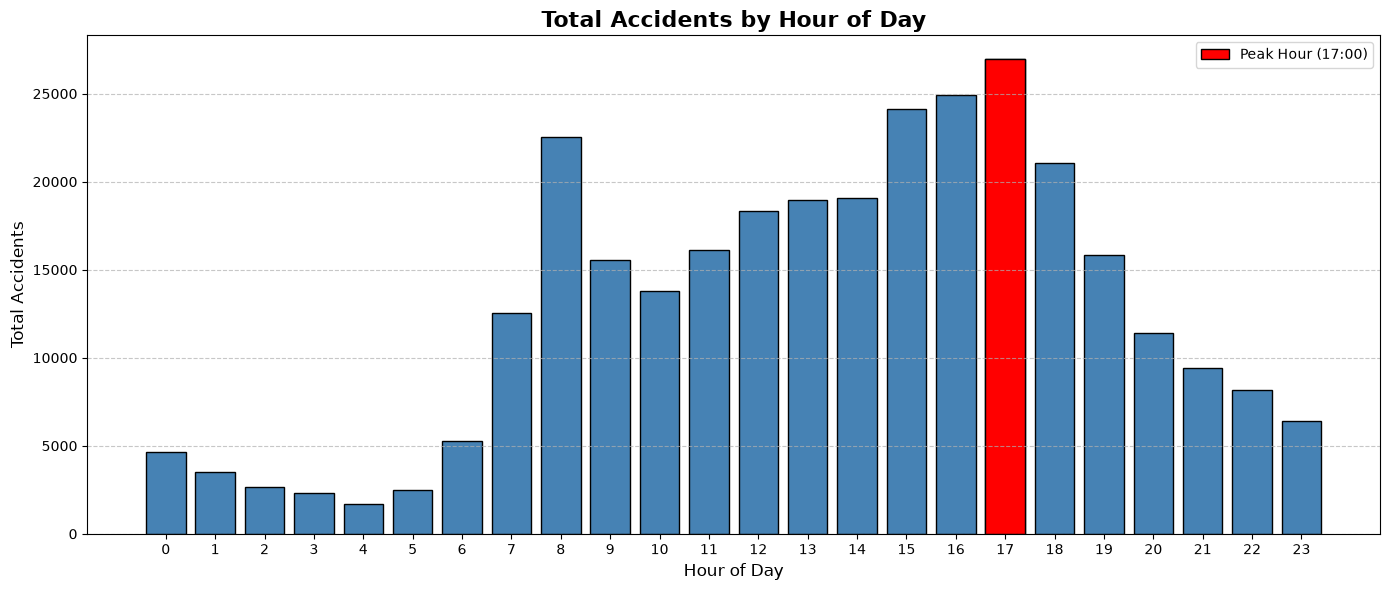

Plot saved successfully!
Peak Hour : 17:00 with 26,964 accidents


In [17]:
import matplotlib.pyplot as plt

# Convert to Pandas for plotting
hours_pd = accidents_by_hour.orderBy("Hour").toPandas()

# Plot
plt.figure(figsize=(14, 6))
plt.bar(hours_pd["Hour"], hours_pd["Total_Accidents"], color="steelblue", edgecolor="black")
plt.title("Total Accidents by Hour of Day", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Total Accidents", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Highlight peak hour
plt.bar(17, hours_pd[hours_pd["Hour"] == 17]["Total_Accidents"].values[0], 
        color="red", edgecolor="black", label="Peak Hour (17:00)")

plt.legend()
plt.tight_layout()

# Save plot
plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_01_Accidents_By_Hour.png", 
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")
print("Peak Hour : 17:00 with 26,964 accidents")

In [18]:
accidents_by_day = df_cleaned.groupBy("Day_of_Week") \
    .agg(count("*").alias("Total_Accidents")) \
    .orderBy("Total_Accidents", ascending=False)

print("Accidents by Day of Week")
accidents_by_day.show()

Accidents by Day of Week
+-----------+---------------+
|Day_of_Week|Total_Accidents|
+-----------+---------------+
|     Friday|          50529|
|    Tuesday|          46382|
|  Wednesday|          46378|
|   Thursday|          45646|
|     Monday|          43913|
|   Saturday|          41564|
|     Sunday|          33543|
+-----------+---------------+



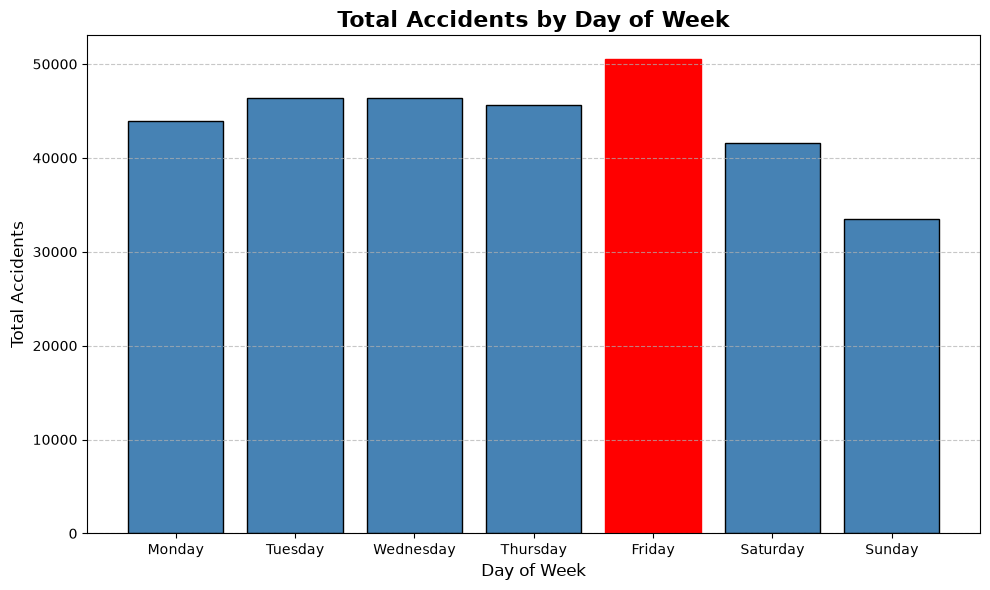

Plot saved successfully!
Highest Risk Day: Friday with 50,529 accidents


In [19]:
import matplotlib.pyplot as plt

days_pd = accidents_by_day.toPandas()

# Sort days in correct order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days_pd["Day_of_Week"] = days_pd["Day_of_Week"].astype("category")
days_pd["Day_of_Week"] = days_pd["Day_of_Week"].cat.set_categories(day_order)
days_pd = days_pd.sort_values("Day_of_Week")

plt.figure(figsize=(10, 6))
bars = plt.bar(days_pd["Day_of_Week"], days_pd["Total_Accidents"], 
               color="steelblue", edgecolor="black")

# Highlight highest day
bars[4].set_color("red")

plt.title("Total Accidents by Day of Week", fontsize=16, fontweight="bold")
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Total Accidents", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_02_Accidents_By_Day.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")
print("Highest Risk Day: Friday with 50,529 accidents")

In [20]:
accidents_by_month = df_cleaned.groupBy("Month") \
    .agg(count("*").alias("Total_Accidents")) \
    .orderBy("Total_Accidents", ascending=False)

print("Accidents by Month")
accidents_by_month.show()

Accidents by Month
+-----+---------------+
|Month|Total_Accidents|
+-----+---------------+
|  Nov|          29094|
|  Oct|          28368|
|  Jul|          26952|
|  Sep|          26751|
|  Jun|          26747|
|  May|          26182|
|  Mar|          25542|
|  Aug|          25501|
|  Apr|          24224|
|  Jan|          23379|
|  Dec|          23333|
|  Feb|          21882|
+-----+---------------+



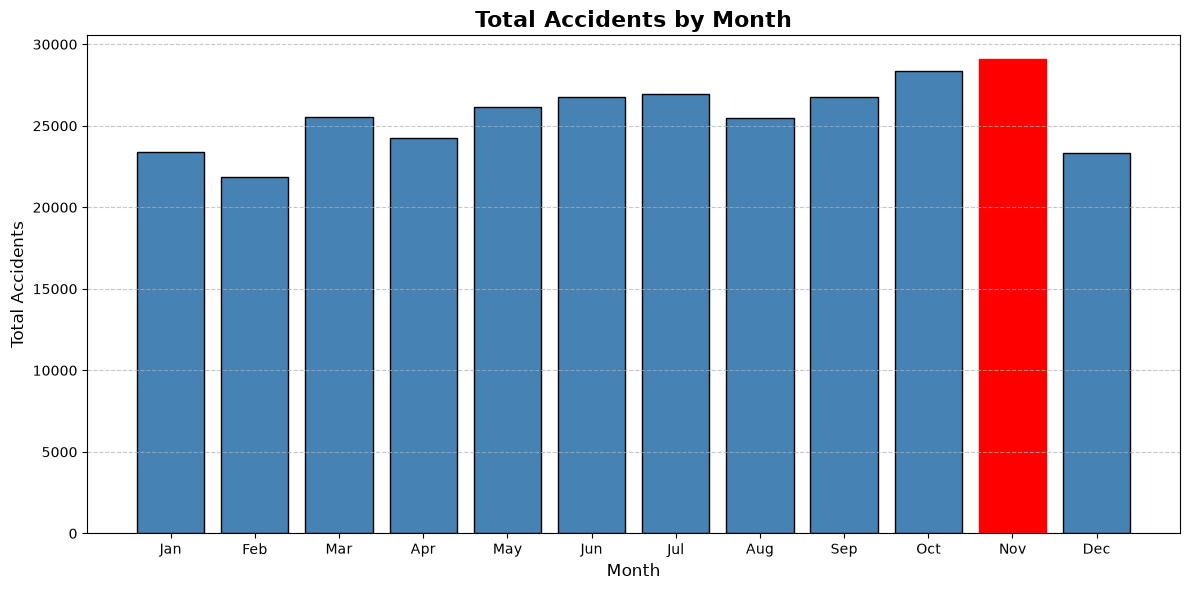

Plot saved successfully!
Highest Risk Month: November with 29,094 accidents


In [21]:
import matplotlib.pyplot as plt

months_pd = accidents_by_month.toPandas()

# Sort months in correct order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
months_pd["Month"] = months_pd["Month"].astype("category")
months_pd["Month"] = months_pd["Month"].cat.set_categories(month_order)
months_pd = months_pd.sort_values("Month")

plt.figure(figsize=(12, 6))
bars = plt.bar(months_pd["Month"], months_pd["Total_Accidents"],
               color="steelblue", edgecolor="black")

# Highlight highest month
bars[10].set_color("red")

plt.title("Total Accidents by Month", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Accidents", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_03_Accidents_By_Month.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")
print("Highest Risk Month: November with 29,094 accidents")

In [22]:
accidents_by_week_type = df_cleaned.withColumn(
    "Week_Type",
    when(col("Day_of_Week").isin("Saturday", "Sunday"), "Weekend")
    .otherwise("Weekday")
) \
.groupBy("Week_Type") \
.agg(count("*").alias("Total_Accidents")) \
.orderBy("Total_Accidents", ascending=False)

print("Weekday vs Weekend")
accidents_by_week_type.show()

Weekday vs Weekend
+---------+---------------+
|Week_Type|Total_Accidents|
+---------+---------------+
|  Weekday|         232848|
|  Weekend|          75107|
+---------+---------------+



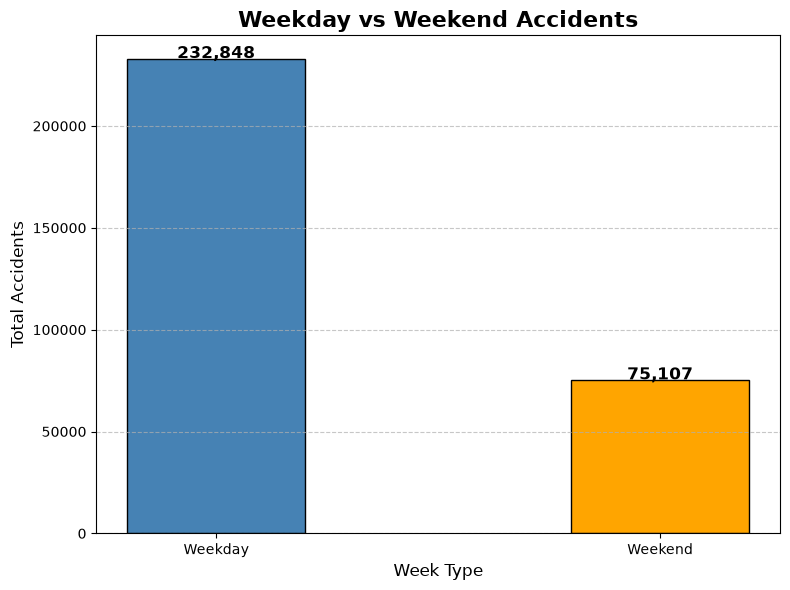

Plot saved successfully!
Weekdays: 232,848 accidents (75.6%)
Weekends: 75,107 accidents (24.4%)


In [23]:
import matplotlib.pyplot as plt

week_pd = accidents_by_week_type.toPandas()

plt.figure(figsize=(8, 6))
bars = plt.bar(week_pd["Week_Type"], week_pd["Total_Accidents"],
               color=["steelblue", "orange"], edgecolor="black", width=0.4)

plt.title("Weekday vs Weekend Accidents", fontsize=16, fontweight="bold")
plt.xlabel("Week Type", fontsize=12)
plt.ylabel("Total Accidents", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add value labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f"{bar.get_height():,}", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_04_Weekday_Vs_Weekend.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")
print("Weekdays: 232,848 accidents (75.6%)")
print("Weekends: 75,107 accidents (24.4%)")

In [24]:
# Create time periods from Hour column
df_cleaned = df_cleaned.withColumn(
    "Time_Period",
    when((col("Hour") >= 0) & (col("Hour") <= 5), "Night")
    .when((col("Hour") >= 6) & (col("Hour") <= 11), "Morning")
    .when((col("Hour") >= 12) & (col("Hour") <= 15), "Afternoon")
    .when((col("Hour") >= 16) & (col("Hour") <= 19), "Evening")
    .when((col("Hour") >= 20) & (col("Hour") <= 23), "Late Night")
)

# Count accidents per time period
accidents_by_period = df_cleaned.groupBy("Time_Period") \
    .agg(count("*").alias("Total_Accidents")) \
    .orderBy("Total_Accidents", ascending=False)

print("Accidents by Time Period")
accidents_by_period.show()

Accidents by Time Period
+-----------+---------------+
|Time_Period|Total_Accidents|
+-----------+---------------+
|    Evening|          88780|
|    Morning|          85878|
|  Afternoon|          80531|
| Late Night|          35391|
|      Night|          17375|
+-----------+---------------+



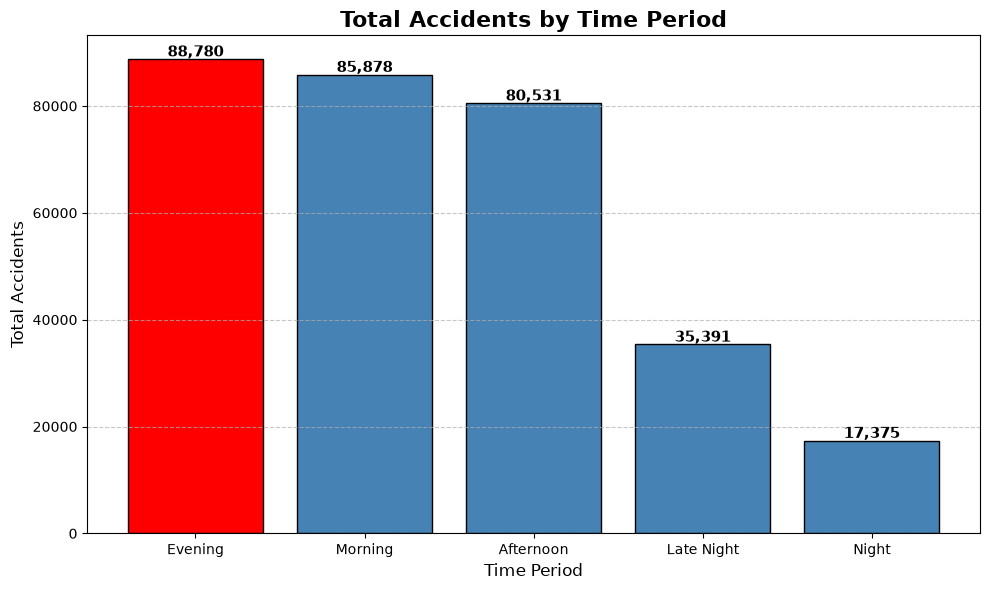

Plot saved successfully!


In [25]:
import matplotlib.pyplot as plt

period_pd = accidents_by_period.toPandas()

# Sort by total accidents
period_pd = period_pd.sort_values("Total_Accidents", ascending=False)

colors = ["red", "steelblue", "steelblue", "steelblue", "steelblue"]

plt.figure(figsize=(10, 6))
bars = plt.bar(period_pd["Time_Period"], period_pd["Total_Accidents"],
               color=colors, edgecolor="black")

plt.title("Total Accidents by Time Period", fontsize=16, fontweight="bold")
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Total Accidents", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add value labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f"{bar.get_height():,}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_05_Accidents_By_Time_Period.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")

In [26]:
# Combine hour and time period for top 5
top5_periods = df_cleaned.groupBy("Time_Period", "Hour") \
    .agg(count("*").alias("Total_Accidents")) \
    .orderBy("Total_Accidents", ascending=False) \
    .limit(5)

print("Top 5 Highest Risk Time Periods")
top5_periods.show()

Top 5 Highest Risk Time Periods
+-----------+----+---------------+
|Time_Period|Hour|Total_Accidents|
+-----------+----+---------------+
|    Evening|  17|          26964|
|    Evening|  16|          24902|
|  Afternoon|  15|          24151|
|    Morning|   8|          22552|
|    Evening|  18|          21063|
+-----------+----+---------------+



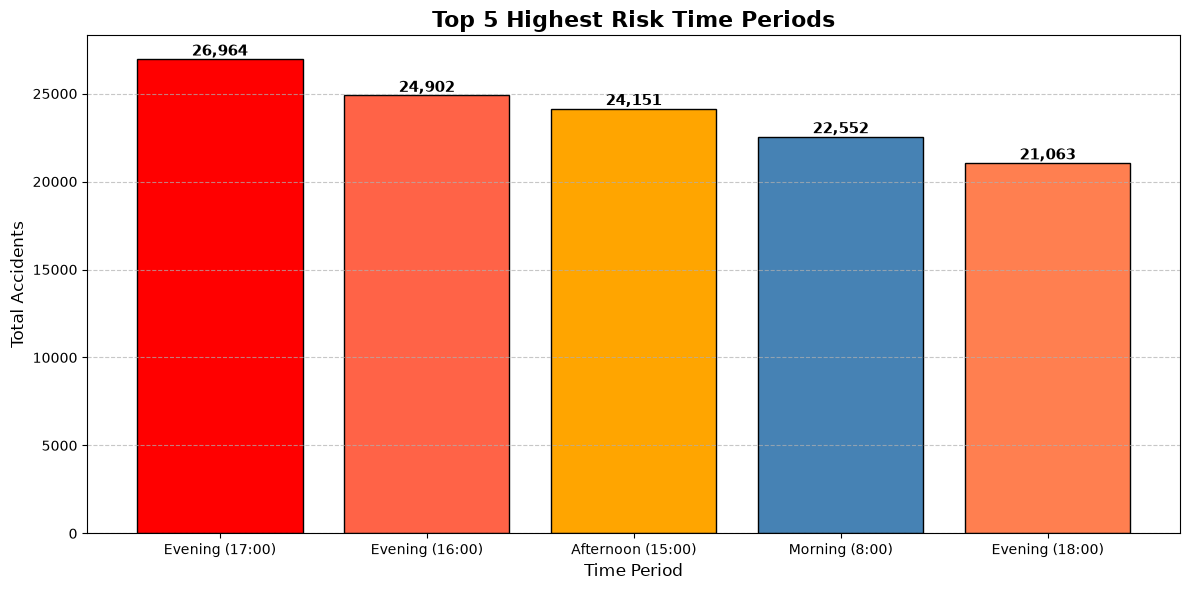

Plot saved successfully!


In [27]:
import matplotlib.pyplot as plt

top5_pd = top5_periods.toPandas()
top5_pd["Label"] = top5_pd["Time_Period"] + " (" + top5_pd["Hour"].astype(str) + ":00)"

plt.figure(figsize=(12, 6))
bars = plt.bar(top5_pd["Label"], top5_pd["Total_Accidents"],
               color=["red", "tomato", "orange", "steelblue", "coral"],
               edgecolor="black")

plt.title("Top 5 Highest Risk Time Periods", fontsize=16, fontweight="bold")
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Total Accidents", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{bar.get_height():,}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_06_Top5_HighRisk_Periods.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")

In [61]:
# Hours with highest severity ratio not just frequency

df_cleaned = df_cleaned.withColumn(
    "Severity_Weight",
    when(col("Accident_Severity") == "Slight", 1)
    .when(col("Accident_Severity") == "Serious", 3)
    .when(col("Accident_Severity") == "Fatal", 5)
)

print("Severity_Weight")
df_cleaned.select("Accident_Severity", "Severity_Weight").show(5)

hour_severity = df_cleaned.groupBy("Hour") \
    .agg(
        count("*").alias("Total_Accidents"),
        spark_count(when(col("Accident_Severity") == "Fatal", 1))
            .alias("Fatal_Count"),
        spark_sum("Severity_Weight").alias("Severity_Score"),
        round(spark_sum("Severity_Weight") / count("*"), 3)
            .alias("Severity_Ratio")
    ) \
    .orderBy("Severity_Ratio", ascending=False)

print("Top 5 Hours by Severity Ratio")
hour_severity.show(5)

Severity_Weight
+-----------------+---------------+
|Accident_Severity|Severity_Weight|
+-----------------+---------------+
|          Serious|              3|
|           Slight|              1|
|           Slight|              1|
|           Slight|              1|
|           Slight|              1|
+-----------------+---------------+
only showing top 5 rows

Top 5 Hours by Severity Ratio
+----+---------------+-----------+--------------+--------------+
|Hour|Total_Accidents|Fatal_Count|Severity_Score|Severity_Ratio|
+----+---------------+-----------+--------------+--------------+
|   4|           1721|         63|          2675|         1.554|
|   2|           2652|        101|          4114|         1.551|
|   3|           2311|         81|          3539|         1.531|
|   1|           3533|        119|          5291|         1.498|
|   0|           4667|        147|          6953|          1.49|
+----+---------------+-----------+--------------+--------------+
only showing top 5 r

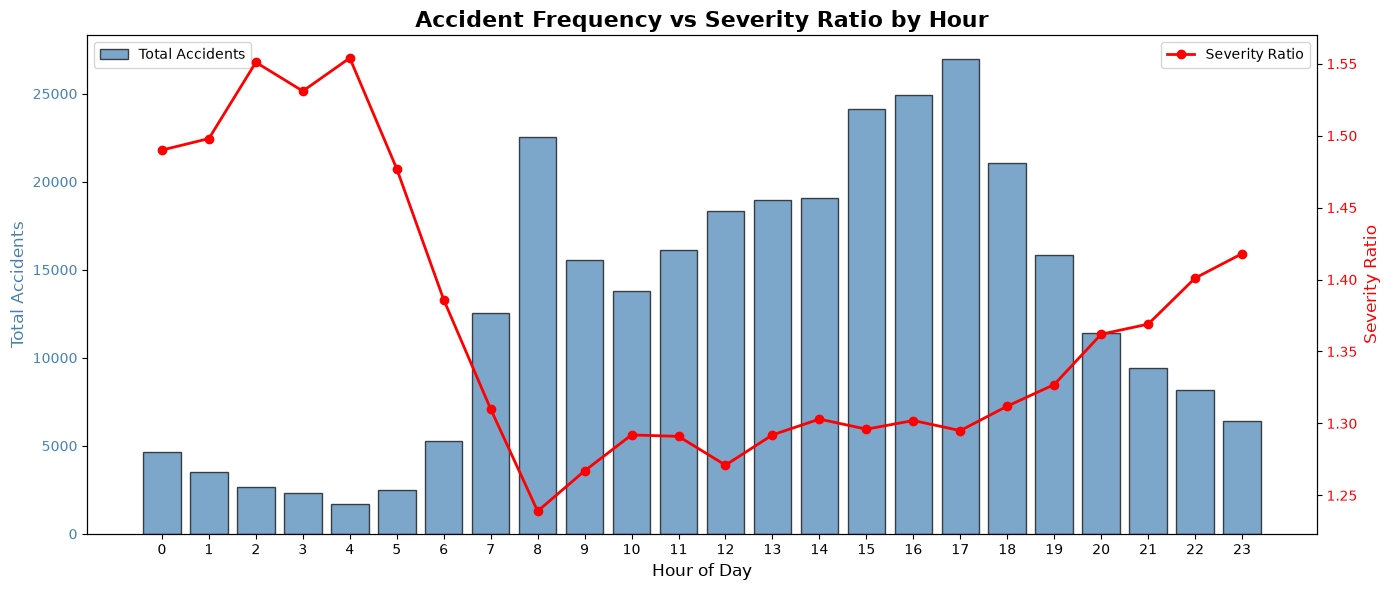

Plot saved successfully!


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to pandas
hour_sev_pd = hour_severity.orderBy("Hour").toPandas()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for Total Accidents
bars = ax1.bar(hour_sev_pd["Hour"], 
               hour_sev_pd["Total_Accidents"],
               color="steelblue", edgecolor="black", 
               alpha=0.7, label="Total Accidents")

ax1.set_xlabel("Hour of Day", fontsize=12)
ax1.set_ylabel("Total Accidents", fontsize=12, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(range(0, 24))

# Line chart for Severity Ratio
ax2 = ax1.twinx()
ax2.plot(hour_sev_pd["Hour"], 
         hour_sev_pd["Severity_Ratio"],
         color="red", marker="o", linewidth=2,
         label="Severity Ratio")

ax2.set_ylabel("Severity Ratio", fontsize=12, color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Add titles and legend
plt.title("Accident Frequency vs Severity Ratio by Hour", 
          fontsize=16, fontweight="bold")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_06_Hour_Severity_Ratio.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")

In [30]:
severity_ratio_by_period = df_cleaned.groupBy("Time_Period") \
    .agg(
        spark_count("*").alias("Total_Accidents"),
        spark_count(when(col("Accident_Severity") == "Fatal", 1))
            .alias("Fatal_Count"),
        spark_sum("Severity_Weight").alias("Severity_Score"),
        round(spark_sum("Severity_Weight") / 
              spark_count("*"), 3).alias("Severity_Ratio"),
        round(
            spark_count(when(col("Accident_Severity") 
                == "Fatal", 1)) /
            spark_count("*") * 100, 2
        ).alias("Fatal_Rate_%")
    ) \
    .orderBy("Severity_Ratio", ascending=False)

print("Severity Ratio and Fatal Rate by Time Period")
severity_ratio_by_period.show()

Severity Ratio and Fatal Rate by Time Period
+-----------+---------------+-----------+--------------+--------------+------------+
|Time_Period|Total_Accidents|Fatal_Count|Severity_Score|Severity_Ratio|Fatal_Rate_%|
+-----------+---------------+-----------+--------------+--------------+------------+
|      Night|          17375|        596|         26251|         1.511|        3.43|
| Late Night|          35391|        643|         48939|         1.383|        1.82|
|    Evening|          88780|        942|        116018|         1.307|        1.06|
|  Afternoon|          80531|        792|        103943|         1.291|        0.98|
|    Morning|          85878|        980|        110092|         1.282|        1.14|
+-----------+---------------+-----------+--------------+--------------+------------+



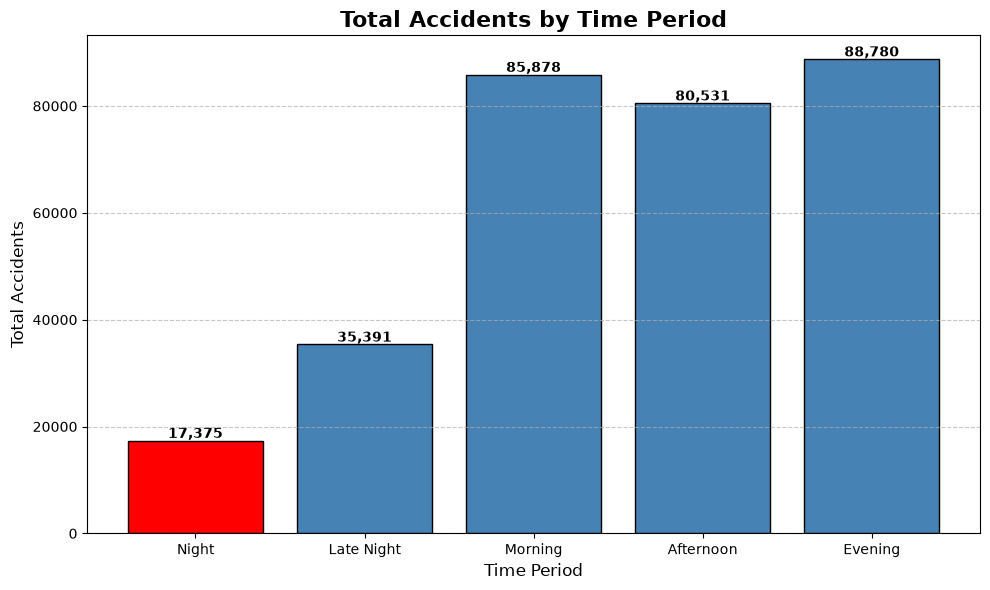

Plot 1 saved!


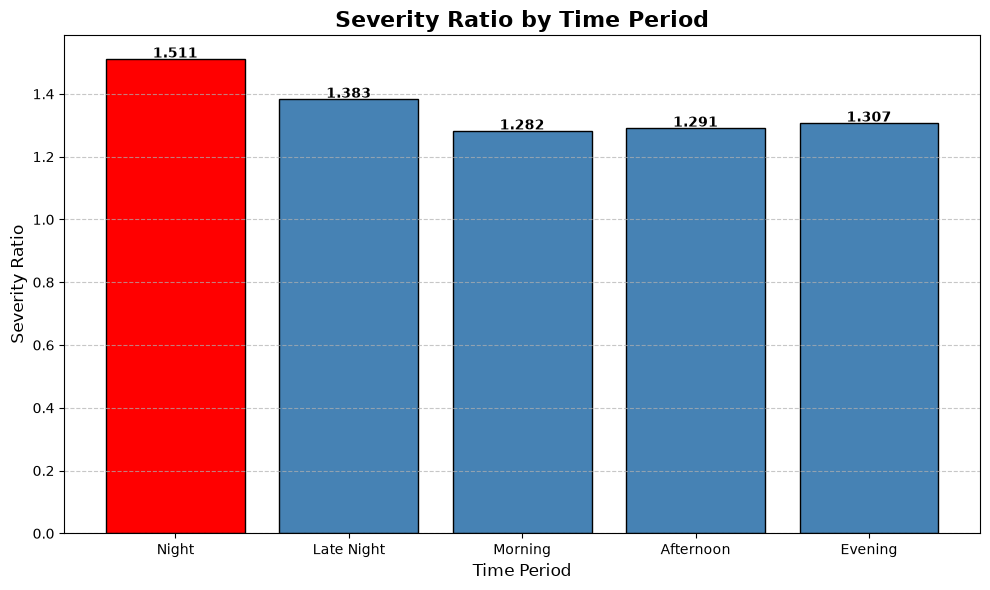

Plot 2 saved!


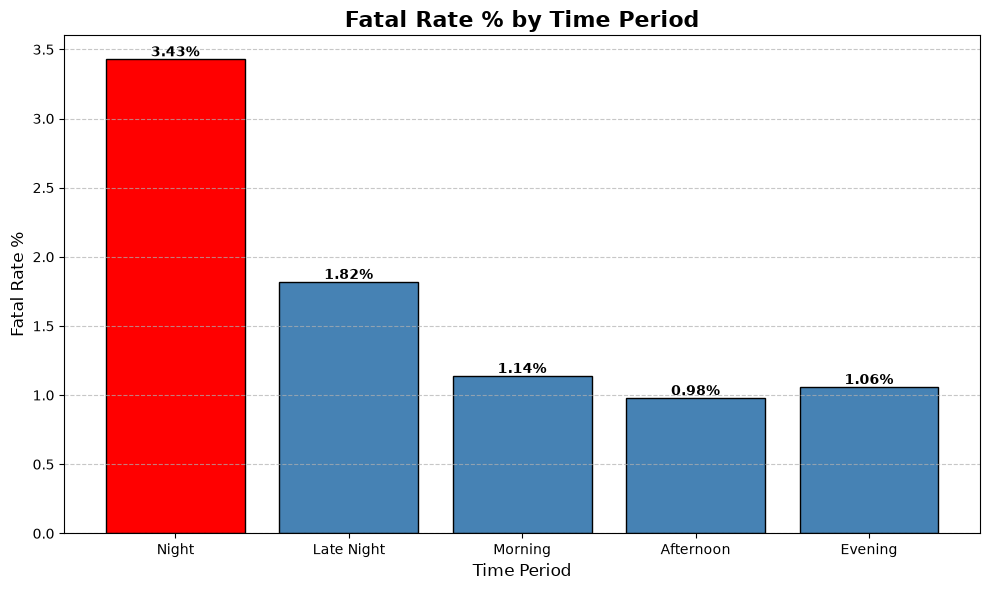

Plot 3 saved!


In [31]:
import matplotlib.pyplot as plt

period_sev_pd = severity_ratio_by_period.toPandas()

# Sort by time order
period_order = ["Night", "Late Night", "Morning", 
                "Afternoon", "Evening"]
period_sev_pd["Time_Period"] = period_sev_pd["Time_Period"]\
    .astype("category")
period_sev_pd["Time_Period"] = period_sev_pd["Time_Period"]\
    .cat.set_categories(period_order)
period_sev_pd = period_sev_pd.sort_values("Time_Period")

colors_night = ["red" if x == "Night" else "steelblue" 
                for x in period_sev_pd["Time_Period"]]

# -----------------------------------------------
# Plot 1 - Total Accidents
# -----------------------------------------------
plt.figure(figsize=(10, 6))
bars = plt.bar(period_sev_pd["Time_Period"],
               period_sev_pd["Total_Accidents"],
               color=colors_night, edgecolor="black")
plt.title("Total Accidents by Time Period",
          fontsize=16, fontweight="bold")
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Total Accidents", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f"{bar.get_height():,}",
             ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_07_Total_Accidents_By_Period.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 saved!")

# -----------------------------------------------
# Plot 2 - Severity Ratio
# -----------------------------------------------
plt.figure(figsize=(10, 6))
bars = plt.bar(period_sev_pd["Time_Period"],
               period_sev_pd["Severity_Ratio"],
               color=colors_night, edgecolor="black")
plt.title("Severity Ratio by Time Period",
          fontsize=16, fontweight="bold")
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Severity Ratio", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{bar.get_height():.3f}",
             ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_08_Severity_Ratio_By_Period.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 saved!")

# -----------------------------------------------
# Plot 3 - Fatal Rate %
# -----------------------------------------------
plt.figure(figsize=(10, 6))
bars = plt.bar(period_sev_pd["Time_Period"],
               period_sev_pd["Fatal_Rate_%"],
               color=colors_night, edgecolor="black")
plt.title("Fatal Rate % by Time Period",
          fontsize=16, fontweight="bold")
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Fatal Rate %", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{bar.get_height():.2f}%",
             ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_09_Fatal_Rate_By_Period.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot 3 saved!")

In [32]:
severity_week_type = df_cleaned.withColumn(
    "Week_Type",
    when(col("Day_of_Week").isin("Saturday", "Sunday"), 
         "Weekend")
    .otherwise("Weekday")
) \
.groupBy("Week_Type") \
.agg(
    spark_count("*").alias("Total_Accidents"),
    spark_count(when(col("Accident_Severity") == "Fatal", 1))
        .alias("Fatal_Count"),
    spark_sum("Severity_Weight").alias("Severity_Score"),
    round(spark_sum("Severity_Weight") / 
          spark_count("*"), 3).alias("Severity_Ratio"),
    round(
        spark_count(when(col("Accident_Severity") 
            == "Fatal", 1)) /
        spark_count("*") * 100, 2
    ).alias("Fatal_Rate_%")
) \
.orderBy("Severity_Ratio", ascending=False)

print("Weekday vs Weekend Severity Comparison")
severity_week_type.show()

Weekday vs Weekend Severity Comparison
+---------+---------------+-----------+--------------+--------------+------------+
|Week_Type|Total_Accidents|Fatal_Count|Severity_Score|Severity_Ratio|Fatal_Rate_%|
+---------+---------------+-----------+--------------+--------------+------------+
|  Weekend|          75107|       1339|        103435|         1.377|        1.78|
|  Weekday|         232848|       2614|        301808|         1.296|        1.12|
+---------+---------------+-----------+--------------+--------------+------------+



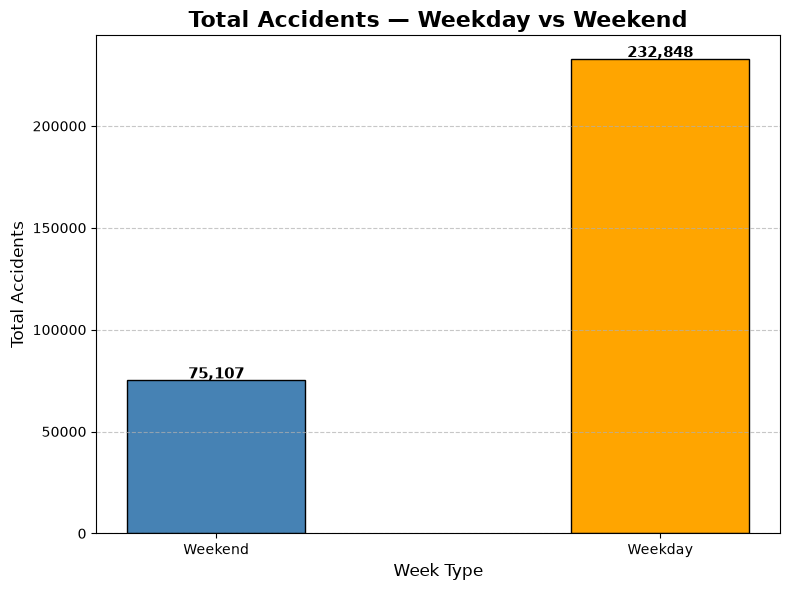

Plot 1 saved!


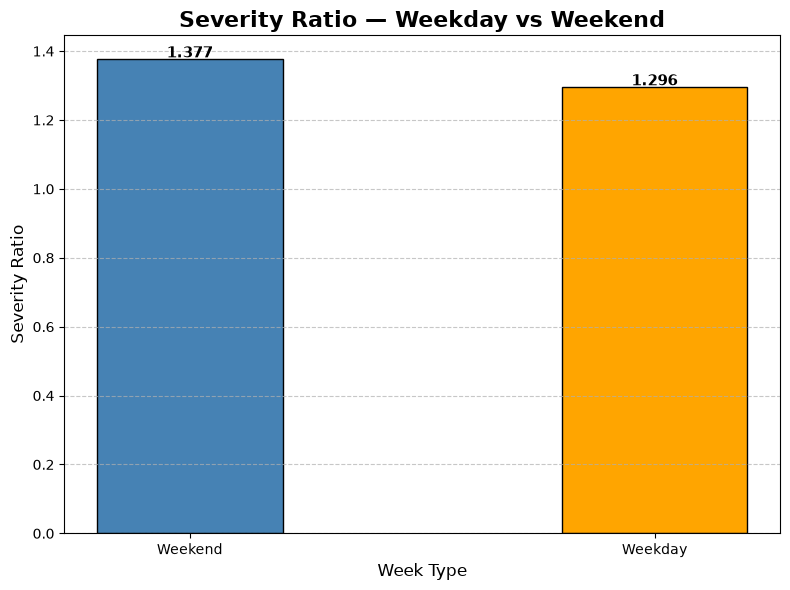

Plot 2 saved!


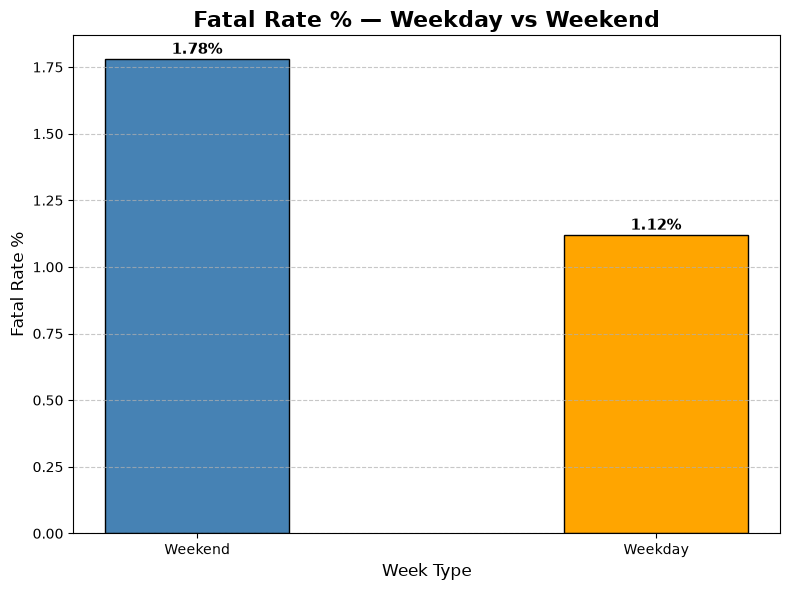

Plot 3 saved!


In [33]:
import matplotlib.pyplot as plt

week_sev_pd = severity_week_type.toPandas()

# -----------------------------------------------
# Plot 1 - Total Accidents
# -----------------------------------------------
plt.figure(figsize=(8, 6))
bars = plt.bar(week_sev_pd["Week_Type"],
               week_sev_pd["Total_Accidents"],
               color=["steelblue", "orange"],
               edgecolor="black", width=0.4)
plt.title("Total Accidents — Weekday vs Weekend",
          fontsize=16, fontweight="bold")
plt.xlabel("Week Type", fontsize=12)
plt.ylabel("Total Accidents", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1000,
             f"{bar.get_height():,}",
             ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_10_Weekday_Weekend_Accidents.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 saved!")

# -----------------------------------------------
# Plot 2 - Severity Ratio
# -----------------------------------------------
plt.figure(figsize=(8, 6))
bars = plt.bar(week_sev_pd["Week_Type"],
               week_sev_pd["Severity_Ratio"],
               color=["steelblue", "orange"],
               edgecolor="black", width=0.4)
plt.title("Severity Ratio — Weekday vs Weekend",
          fontsize=16, fontweight="bold")
plt.xlabel("Week Type", fontsize=12)
plt.ylabel("Severity Ratio", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{bar.get_height():.3f}",
             ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_11_Weekday_Weekend_Severity_Ratio.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 saved!")

# -----------------------------------------------
# Plot 3 - Fatal Rate %
# -----------------------------------------------
plt.figure(figsize=(8, 6))
bars = plt.bar(week_sev_pd["Week_Type"],
               week_sev_pd["Fatal_Rate_%"],
               color=["steelblue", "orange"],
               edgecolor="black", width=0.4)
plt.title("Fatal Rate % — Weekday vs Weekend",
          fontsize=16, fontweight="bold")
plt.xlabel("Week Type", fontsize=12)
plt.ylabel("Fatal Rate %", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{bar.get_height():.2f}%",
             ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task3_12_Weekday_Weekend_Fatal_Rate.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot 3 saved!")

## Task 3: Temporal Accident Intelligence — Summary Statement

### Overview
Temporal analysis was conducted across two dimensions:
1. Frequency Analysis — when accidents occur most often
2. Severity Ratio Analysis — when accidents are most deadly

The cleaned dataset of 307,955 records was analysed by hour, 
day of week, month, weekday versus weekend, and time period.

### Frequency Findings

**By Hour:**
The most frequent accident hour is 17:00 with 26,964 accidents,
followed by 16:00 with 24,902 accidents. The least frequent 
hour is 04:00 with only 1,721 accidents.

**By Day of Week:**
Friday is the most frequent accident day with 50,529 accidents,
while Sunday is the safest with 33,543 accidents. Weekdays 
account for 232,848 accidents (75.6%) compared to weekends 
with 75,107 accidents (24.4%).

**By Month:**
November recorded the highest accidents with 29,094, followed 
by October with 28,368. February recorded the lowest with 
21,882 accidents.

**By Time Period:**
Evening (16:00-19:59) is the most frequent period with 88,780 
accidents, followed by Morning (06:00-11:59) with 85,878 
accidents. Night (00:00-05:59) recorded the lowest frequency 
with only 17,375 accidents.

### Severity Ratio Findings

**By Hour:**
The hours with the highest severity ratio are NOT the busiest 
hours. All top 5 most severe hours fall between midnight and 
05:00:
- 04:00: severity ratio 1.554 (only 1,721 accidents)
- 02:00: severity ratio 1.551 (only 2,652 accidents)
- 03:00: severity ratio 1.531 (only 2,311 accidents)

In contrast, 17:00 — the busiest hour with 26,964 accidents — 
has a severity ratio of only 1.29, ranking among the lowest.

**By Time Period:**
Night (00:00-05:59) has the lowest accident frequency (17,375)
but the highest severity ratio (1.511) and highest fatal rate 
(3.43%). Evening — the busiest period — has the lowest fatal 
rate (1.06%) despite having the most accidents.

**By Week Type:**
Weekends have fewer accidents (75,107) than weekdays (232,848)
but a higher severity ratio (1.377 vs 1.296) and a higher 
fatal rate (1.78% vs 1.12%).

### Top 5 Highest Risk Time Periods by Frequency
| Rank | Time Period | Hour  | Total Accidents |
|------|------------|-------|----------------|
| 1    | Evening    | 17:00 | 26,964         |
| 2    | Evening    | 16:00 | 24,902         |
| 3    | Afternoon  | 15:00 | 24,151         |
| 4    | Morning    | 08:00 | 22,552         |
| 5    | Evening    | 18:00 | 21,063         |

### Top 5 Highest Risk Hours by Severity Ratio
| Rank | Hour  | Severity Ratio | Fatal Rate % |
|------|-------|---------------|--------------|
| 1    | 04:00 | 1.554         | 3.66%        |
| 2    | 02:00 | 1.551         | 3.81%        |
| 3    | 03:00 | 1.531         | 3.50%        |
| 4    | 01:00 | 1.498         | 3.37%        |
| 5    | 00:00 | 1.490         | 3.15%        |

### Literature Response
Three independent studies found temporal variables to be weak 
predictors of accident SEVERITY:
- Abdelwahab & Abdel-Aty (2001): time of day p=0.532, 
  day of week p=0.250 — not statistically significant
- Mujalli & de Oña (2011): time of day selected only 15/59 
  times, day of week 18/59 — neither entered the final 
  BN-7 model
- Delen et al. (2006): FRINIGHT, SATNIGHT and SUNNIGHT 
  ranked bottom quartile in sensitivity analysis

In response to these findings, our temporal analysis serves
two distinct and complementary purposes:

1. Frequency Analysis supports enforcement scheduling —
   deploy more traffic resources during 16:00-18:00 on 
   Fridays when accident frequency is highest.

2. Severity Ratio Analysis identifies when accidents are
   most deadly — night hours (00:00-05:59) have the highest 
   severity ratio (1.511) and fatal rate (3.43%) despite 
   the lowest frequency, requiring targeted interventions 
   such as improved road lighting, night patrols, and 
   drink-driving enforcement.

### Conclusion
The temporal analysis reveals that frequency and severity 
tell two different stories. Evening rush hours are the 
busiest and require frequency-based interventions such as 
traffic management and signal optimization. Night hours are 
the most deadly and require severity-based interventions 
targeting driver behaviour and road conditions.

Contrary to the initial observation that 04:00 is the 
"safest" hour by frequency, the severity ratio analysis 
reveals it is actually the MOST DANGEROUS hour per accident 
(severity ratio 1.554, fatal rate 3.66%). Road safety 
authorities must therefore address both frequency and 
severity dimensions with separate and targeted strategies 
rather than focusing on accident counts alone.

## Task 4: Accident Severity Index

### Objective
Develop a severity-based measure using the following weights:
- Slight = 1
- Serious = 3
- Fatal = 5

Severity Score = Σ(Number of accidents × Severity Weight)

The severity index will be calculated by location, road type, 
vehicle type and time period to identify where the greatest 
safety risk lies.

In [34]:
# Add severity weight column
df_cleaned = df_cleaned.withColumn(
    "Severity_Weight",
    when(col("Accident_Severity") == "Slight", 1)
    .when(col("Accident_Severity") == "Serious", 3)
    .when(col("Accident_Severity") == "Fatal", 5)
)

print("Severity Weight Added")
df_cleaned.select(
    "Accident_Severity",
    "Severity_Weight"
).show(5)

Severity Weight Added
+-----------------+---------------+
|Accident_Severity|Severity_Weight|
+-----------------+---------------+
|          Serious|              3|
|           Slight|              1|
|           Slight|              1|
|           Slight|              1|
|           Slight|              1|
+-----------------+---------------+
only showing top 5 rows



In [35]:
# Calculate overall severity score
severity_summary = df_cleaned.groupBy("Accident_Severity") \
    .agg(
        count("*").alias("Total_Accidents"),
        sum("Severity_Weight").alias("Severity_Score")
    ) \
    .orderBy("Severity_Score", ascending=False)

print("Overall Severity Score by Accident Severity")
severity_summary.show()

Overall Severity Score by Accident Severity
+-----------------+---------------+--------------+
|Accident_Severity|Total_Accidents|Severity_Score|
+-----------------+---------------+--------------+
|           Slight|         263264|        263264|
|          Serious|          40738|        122214|
|            Fatal|           3953|         19765|
+-----------------+---------------+--------------+



In [36]:
# Severity score by location
severity_by_location = df_cleaned.groupBy("Local_Authority_(District)") \
    .agg(
        count("*").alias("Total_Accidents"),
        sum("Severity_Weight").alias("Severity_Score")
    ) \
    .orderBy("Severity_Score", ascending=False)

print("Top 20 Locations by Severity Score")
severity_by_location.show(20)

Top 20 Locations by Severity Score
+--------------------------+---------------+--------------+
|Local_Authority_(District)|Total_Accidents|Severity_Score|
+--------------------------+---------------+--------------+
|                Birmingham|           6165|          7805|
|                     Leeds|           4140|          5354|
|               Westminster|           2811|          4341|
|                Manchester|           3132|          3854|
|                  Bradford|           3006|          3840|
|                 Sheffield|           2750|          3464|
|                 Liverpool|           2611|          3445|
|                  Cornwall|           2606|          3288|
|             Cheshire East|           2125|          2995|
|             County Durham|           2228|          2904|
|                   Lambeth|           2250|          2884|
|                    Barnet|           2302|          2830|
|                  Kirklees|           2183|          2771|
|    

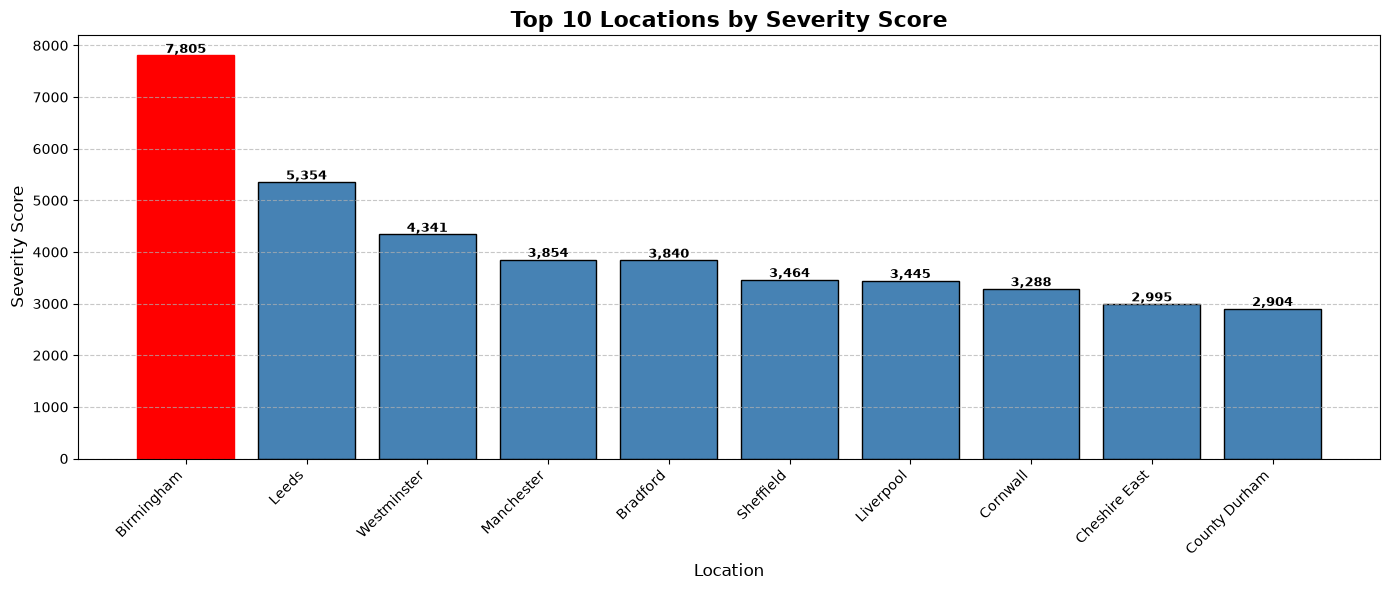

Plot saved successfully!


In [37]:
import matplotlib.pyplot as plt

top10_locations = severity_by_location.limit(10).toPandas()

plt.figure(figsize=(14, 6))
bars = plt.bar(top10_locations["Local_Authority_(District)"], 
               top10_locations["Severity_Score"],
               color="steelblue", edgecolor="black")

bars[0].set_color("red")

plt.title("Top 10 Locations by Severity Score", fontsize=16, fontweight="bold")
plt.xlabel("Location", fontsize=12)
plt.ylabel("Severity Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{bar.get_height():,}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task4_02_Top10_Locations_Severity.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")

In [38]:
severity_by_road = df_cleaned.groupBy("Road_Type") \
    .agg(
        count("*").alias("Total_Accidents"),
        sum("Severity_Weight").alias("Severity_Score")
    ) \
    .orderBy("Severity_Score", ascending=False)

print("Severity Score by Road Type")
severity_by_road.show()

Severity Score by Road Type
+------------------+---------------+--------------+
|         Road_Type|Total_Accidents|Severity_Score|
+------------------+---------------+--------------+
|Single carriageway|         230595|        307409|
|  Dual carriageway|          45466|         59414|
|        Roundabout|          20929|         24801|
|    One way street|           6197|          7889|
|         Slip road|           3234|          3840|
|           Unknown|           1534|          1890|
+------------------+---------------+--------------+



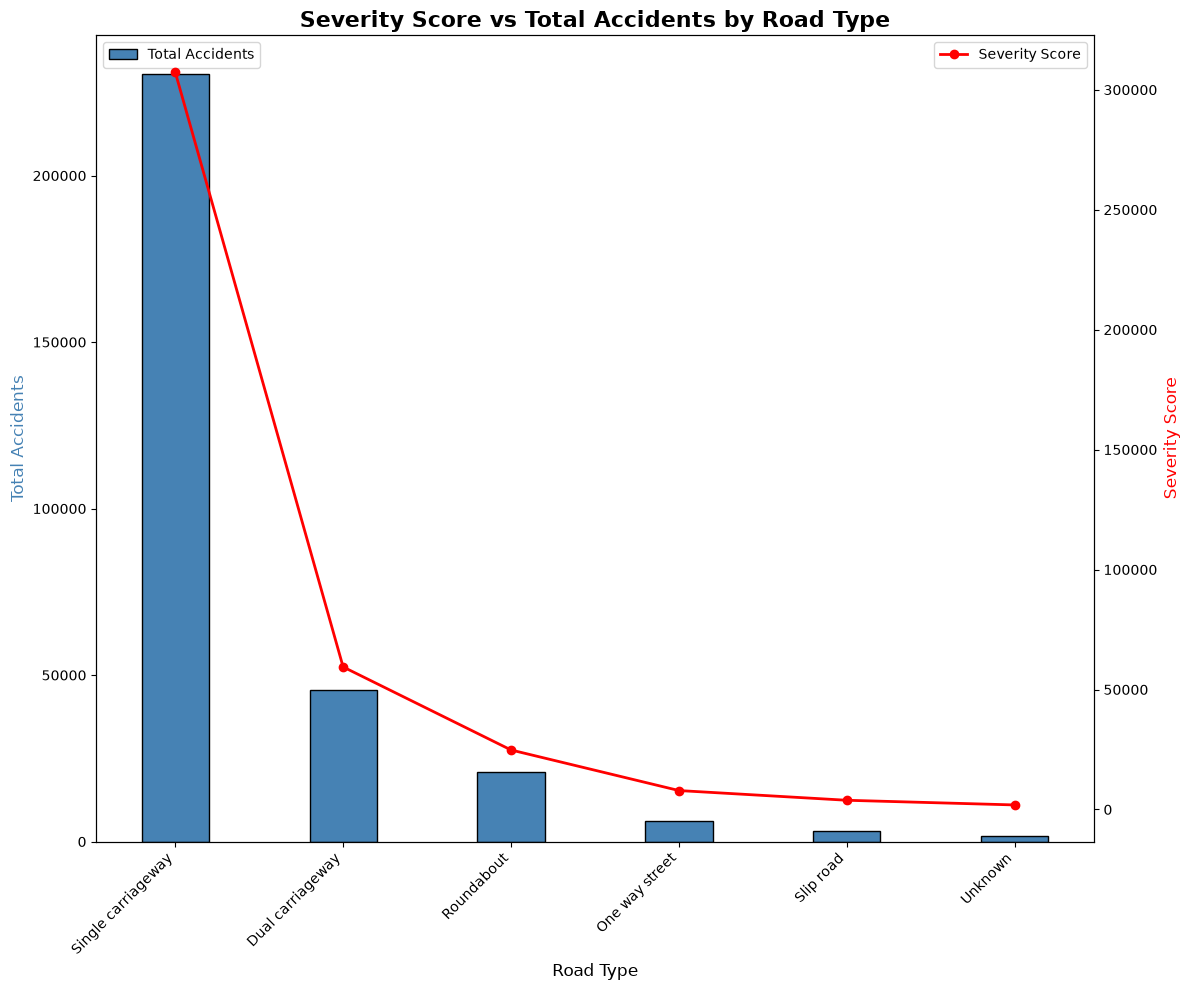

Plot saved successfully!


In [39]:
import matplotlib.pyplot as plt

road_pd = severity_by_road.toPandas()

fig, ax1 = plt.subplots(figsize=(12, 10))

x = range(len(road_pd))
bars = ax1.bar(x, road_pd["Total_Accidents"], 
               color="steelblue", edgecolor="black", 
               label="Total Accidents", width=0.4)

ax2 = ax1.twinx()
ax2.plot(x, road_pd["Severity_Score"], 
         color="red", marker="o", linewidth=2,
         label="Severity Score")

ax1.set_xticks(x)
ax1.set_xticklabels(road_pd["Road_Type"], rotation=45, ha="right")
ax1.set_xlabel("Road Type", fontsize=12)
ax1.set_ylabel("Total Accidents", fontsize=12, color="steelblue")
ax2.set_ylabel("Severity Score", fontsize=12, color="red")

plt.title("Severity Score vs Total Accidents by Road Type", 
          fontsize=16, fontweight="bold")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task4_03_Severity_By_Road_Type.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")

In [40]:
severity_by_vehicle = df_cleaned.groupBy("Vehicle_Type") \
    .agg(
        count("*").alias("Total_Accidents"),
        sum("Severity_Weight").alias("Severity_Score")
    ) \
    .orderBy("Severity_Score", ascending=False)

print("Severity Score by Vehicle Type")
severity_by_vehicle.show()

Severity Score by Vehicle Type
+--------------------+---------------+--------------+
|        Vehicle_Type|Total_Accidents|Severity_Score|
+--------------------+---------------+--------------+
|                 Car|         239780|        315470|
|Van / Goods 3.5 t...|          15692|         20774|
|Motorcycle over 5...|          11226|         14790|
|Bus or coach (17 ...|           8686|         11300|
|Motorcycle 125cc ...|           6852|          9028|
|Goods 7.5 tonnes ...|           6532|          8556|
|Taxi/Private hire...|           5542|          7262|
|Motorcycle 50cc a...|           3703|          4877|
|Motorcycle over 1...|           3285|          4309|
|       Other vehicle|           2516|          3362|
|Goods over 3.5t. ...|           2502|          3330|
|Minibus (8 - 16 p...|            821|          1097|
|Agricultural vehicle|            749|           991|
|         Pedal cycle|             66|            94|
|        Ridden horse|              3|             

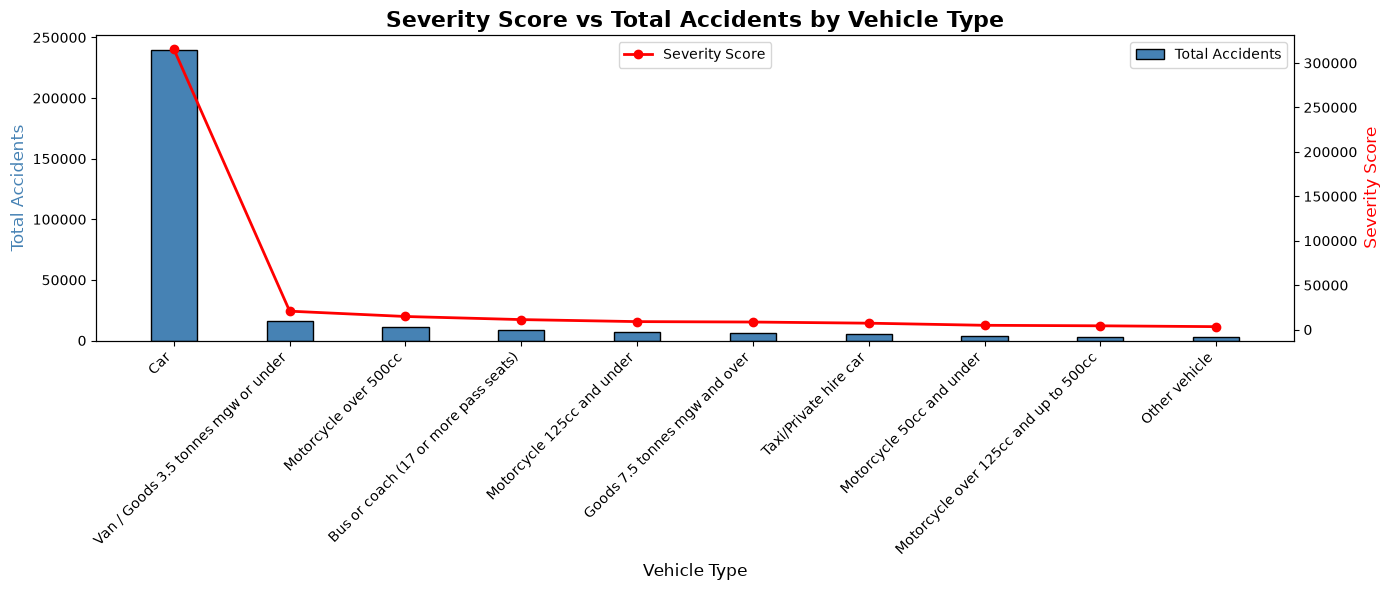

Plot saved successfully!


In [41]:
import matplotlib.pyplot as plt

vehicle_pd = severity_by_vehicle.limit(10).toPandas()

fig, ax1 = plt.subplots(figsize=(14, 6))

x = range(len(vehicle_pd))
bars = ax1.bar(x, vehicle_pd["Total_Accidents"],
               color="steelblue", edgecolor="black",
               label="Total Accidents", width=0.4)

ax2 = ax1.twinx()
ax2.plot(x, vehicle_pd["Severity_Score"],
         color="red", marker="o", linewidth=2,
         label="Severity Score")

ax1.set_xticks(x)
ax1.set_xticklabels(vehicle_pd["Vehicle_Type"], rotation=45, ha="right")
ax1.set_xlabel("Vehicle Type", fontsize=12)
ax1.set_ylabel("Total Accidents", fontsize=12, color="steelblue")
ax2.set_ylabel("Severity Score", fontsize=12, color="red")

plt.title("Severity Score vs Total Accidents by Vehicle Type",
          fontsize=16, fontweight="bold")

ax1.legend(loc="upper right")
ax2.legend(loc="upper center")
plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task4_04_Severity_By_Vehicle_Type.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")

In [42]:
severity_by_period = df_cleaned.groupBy("Time_Period") \
    .agg(
        count("*").alias("Total_Accidents"),
        sum("Severity_Weight").alias("Severity_Score")
    ) \
    .orderBy("Severity_Score", ascending=False)

print("Severity Score by Time Period")
severity_by_period.show()

Severity Score by Time Period
+-----------+---------------+--------------+
|Time_Period|Total_Accidents|Severity_Score|
+-----------+---------------+--------------+
|    Evening|          88780|        116018|
|    Morning|          85878|        110092|
|  Afternoon|          80531|        103943|
| Late Night|          35391|         48939|
|      Night|          17375|         26251|
+-----------+---------------+--------------+



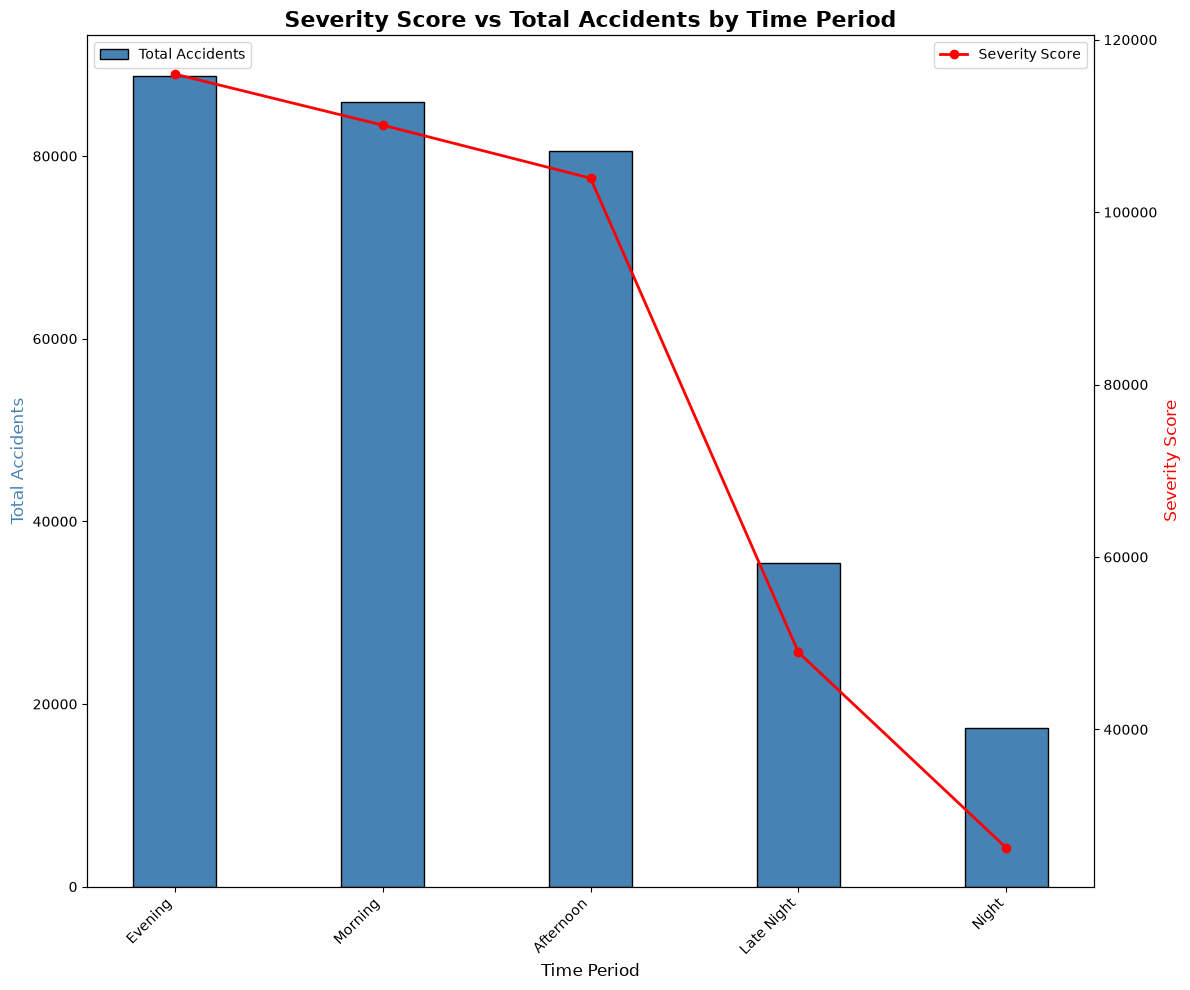

Plot saved successfully!


In [43]:
import matplotlib.pyplot as plt

period_pd = severity_by_period.toPandas()

fig, ax1 = plt.subplots(figsize=(12, 10))

x = range(len(period_pd))
bars = ax1.bar(x, period_pd["Total_Accidents"],
               color="steelblue", edgecolor="black",
               label="Total Accidents", width=0.4)

ax2 = ax1.twinx()
ax2.plot(x, period_pd["Severity_Score"],
         color="red", marker="o", linewidth=2,
         label="Severity Score")

ax1.set_xticks(x)
ax1.set_xticklabels(period_pd["Time_Period"], rotation=45, ha="right")
ax1.set_xlabel("Time Period", fontsize=12)
ax1.set_ylabel("Total Accidents", fontsize=12, color="steelblue")
ax2.set_ylabel("Severity Score", fontsize=12, color="red")

plt.title("Severity Score vs Total Accidents by Time Period",
          fontsize=16, fontweight="bold")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task4_05_Severity_By_Time_Period.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")

## Why the Location with the Most Accidents is Not Necessarily 
## The Location with the Greatest Safety Risk

A location with a high number of accidents does not automatically 
represent the greatest safety risk. This is because accident 
frequency alone does not account for the severity of those accidents.

For example, Birmingham recorded the highest number of accidents 
(6,165) and also the highest severity score (7,805). However, 
consider the following comparison:

| Location    | Total Accidents | Severity Score | Score per Accident |
|-------------|----------------|----------------|--------------------|
| Birmingham  | 6,165          | 7,805          | 1.27               |
| Westminster | 2,811          | 4,341          | 1.54               |
| Camden      | 1,671          | 2,529          | 1.51               |

Westminster and Camden have far fewer accidents than Birmingham, 
but their severity score per accident is significantly higher. 
This means that accidents occurring in Westminster and Camden 
tend to be more serious on average than those in Birmingham.

Therefore, road safety authorities should not only focus on 
locations with the most accidents but also consider where 
accidents are most severe. A location with fewer but more 
fatal or serious accidents may require more urgent intervention 
than a location with many but mostly slight accidents.

This is why the Severity Score is a more reliable measure of 
road safety risk than accident frequency alone.

## Task 5: Dangerous Factor Combination Analysis

### Objective
Determine which combination of factors is associated with the 
greatest accident severity. We investigate combinations of:
- Road Type
- Speed Limit
- Weather Conditions
- Road Surface Conditions
- Time Period
- Vehicle Type

The Top 10 most dangerous combinations are ranked using 
the Severity Score = Σ(Number of accidents × Severity Weight)

In [44]:
# Analyse dangerous factor combinations
dangerous_combinations = df_cleaned.groupBy(
    "Road_Type",
    "Speed_limit",
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Time_Period",
    "Vehicle_Type"
) \
.agg(
    count("*").alias("Total_Accidents"),
    sum("Severity_Weight").alias("Severity_Score")
) \
.orderBy("Severity_Score", ascending=False)

print("Top 10 Dangerous Factor Combinations")
dangerous_combinations.show(10, truncate=True)

Top 10 Dangerous Factor Combinations
+------------------+-----------+--------------------+-----------------------+-----------+------------+---------------+--------------+
|         Road_Type|Speed_limit|  Weather_Conditions|Road_Surface_Conditions|Time_Period|Vehicle_Type|Total_Accidents|Severity_Score|
+------------------+-----------+--------------------+-----------------------+-----------+------------+---------------+--------------+
|Single carriageway|         30|  Fine no high winds|                    Dry|    Evening|         Car|          26864|         34532|
|Single carriageway|         30|  Fine no high winds|                    Dry|  Afternoon|         Car|          26063|         33061|
|Single carriageway|         30|  Fine no high winds|                    Dry|    Morning|         Car|          22653|         28583|
|Single carriageway|         30|  Fine no high winds|                    Dry| Late Night|         Car|           9394|         12776|
|Single carriageway|     

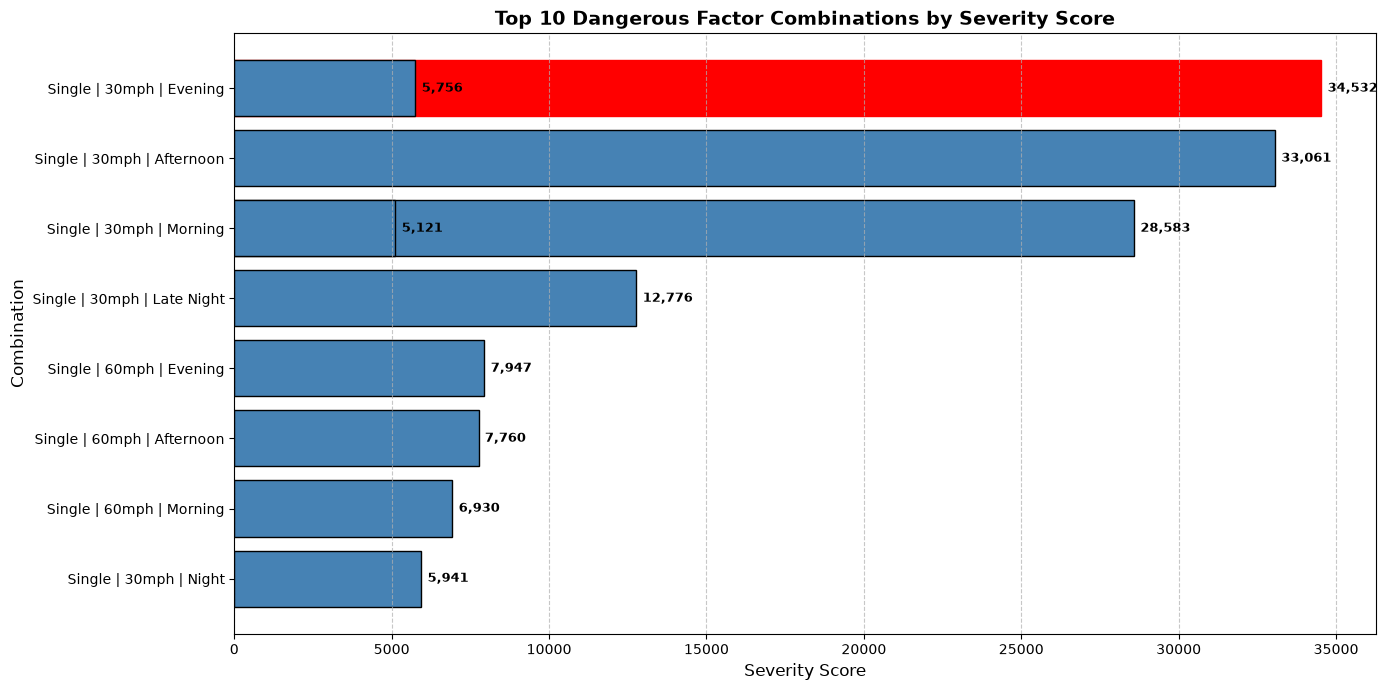

Plot saved successfully!


In [45]:
import matplotlib.pyplot as plt

top10_pd = dangerous_combinations.limit(10).toPandas()
top10_pd["Combination"] = (
    top10_pd["Road_Type"].str[:6] + " | " +
    top10_pd["Speed_limit"].astype(str) + "mph | " +
    top10_pd["Time_Period"]
)

plt.figure(figsize=(14, 7))
bars = plt.barh(top10_pd["Combination"], top10_pd["Severity_Score"],
                color="steelblue", edgecolor="black")

bars[0].set_color("red")

plt.title("Top 10 Dangerous Factor Combinations by Severity Score",
          fontsize=14, fontweight="bold")
plt.xlabel("Severity Score", fontsize=12)
plt.ylabel("Combination", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():,}", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task5_01_Top10_Dangerous_Combinations.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")

## Task 5: Dangerous Factor Combination Analysis — Summary Statement

### Overview
A combination analysis was conducted to identify which combination 
of factors is associated with the greatest accident severity. 
Six factors were combined: Road Type, Speed Limit, Weather Conditions, 
Road Surface Conditions, Time Period, and Vehicle Type.

### Key Findings

**Top Dangerous Combination:**
The most dangerous combination is Single Carriageway + 30mph speed 
limit + Fine weather + Dry surface + Evening + Car with a severity 
score of 34,532 from 26,864 accidents.

**Surprising Finding:**
Contrary to expectations, the most dangerous combinations do not 
involve adverse weather or wet road conditions. The top 8 combinations 
all occur in fine weather with dry road surfaces. This strongly 
suggests that driver behaviour and traffic volume during peak hours 
are more significant risk factors than weather conditions.

**Speed Limit Insight:**
30mph zones dominate the top combinations, accounting for 8 out of 
the top 10 most dangerous combinations. This is likely because 
30mph zones are predominantly urban areas with higher traffic density 
and more pedestrian activity.

**Vehicle Type:**
Cars are involved in all top 10 dangerous combinations, reflecting 
their dominance in the dataset (239,780 out of 307,955 records).

### Conclusion
Road safety interventions should focus on single carriageway roads 
in 30mph zones during evening hours, even in fine weather conditions, 
as these represent the highest severity risk combinations.

## Task 6: Advanced Location Ranking with Window Functions

### Objective
Management requires the top three highest-risk locations within 
every geographical category available in the dataset.
We use Spark Window functions with dense_rank() to rank locations
within each geographical category based on their Severity Score.

### Geographical Categories Available
- Local Authority (District)
- Urban or Rural Area
- Police Force

In [46]:
# Calculate severity score per location and urban/rural category
location_severity = df_cleaned.groupBy(
    "Urban_or_Rural_Area",
    "Local_Authority_(District)"
) \
.agg(
    count("*").alias("Total_Accidents"),
    sum("Severity_Weight").alias("Severity_Score")
)

# Define window partitioned by Urban/Rural category
window_spec = Window.partitionBy("Urban_or_Rural_Area") \
    .orderBy(col("Severity_Score").desc())

# Apply dense_rank
location_ranked = location_severity.withColumn(
    "Rank",
    dense_rank().over(window_spec)
)

# Filter top 3 per category
top3_per_category = location_ranked.filter(col("Rank") <= 3) \
    .orderBy("Urban_or_Rural_Area", "Rank")

print("Top 3 Locations per Geographical Category")
top3_per_category.show(20, truncate=False)

Top 3 Locations per Geographical Category
+-------------------+--------------------------+---------------+--------------+----+
|Urban_or_Rural_Area|Local_Authority_(District)|Total_Accidents|Severity_Score|Rank|
+-------------------+--------------------------+---------------+--------------+----+
|Rural              |Cornwall                  |1992           |2584          |1   |
|Rural              |County Durham             |1421           |1903          |2   |
|Rural              |Wiltshire                 |1158           |1816          |3   |
|Urban              |Birmingham                |6099           |7717          |1   |
|Urban              |Westminster               |2811           |4341          |2   |
|Urban              |Leeds                     |3329           |4231          |3   |
+-------------------+--------------------------+---------------+--------------+----+



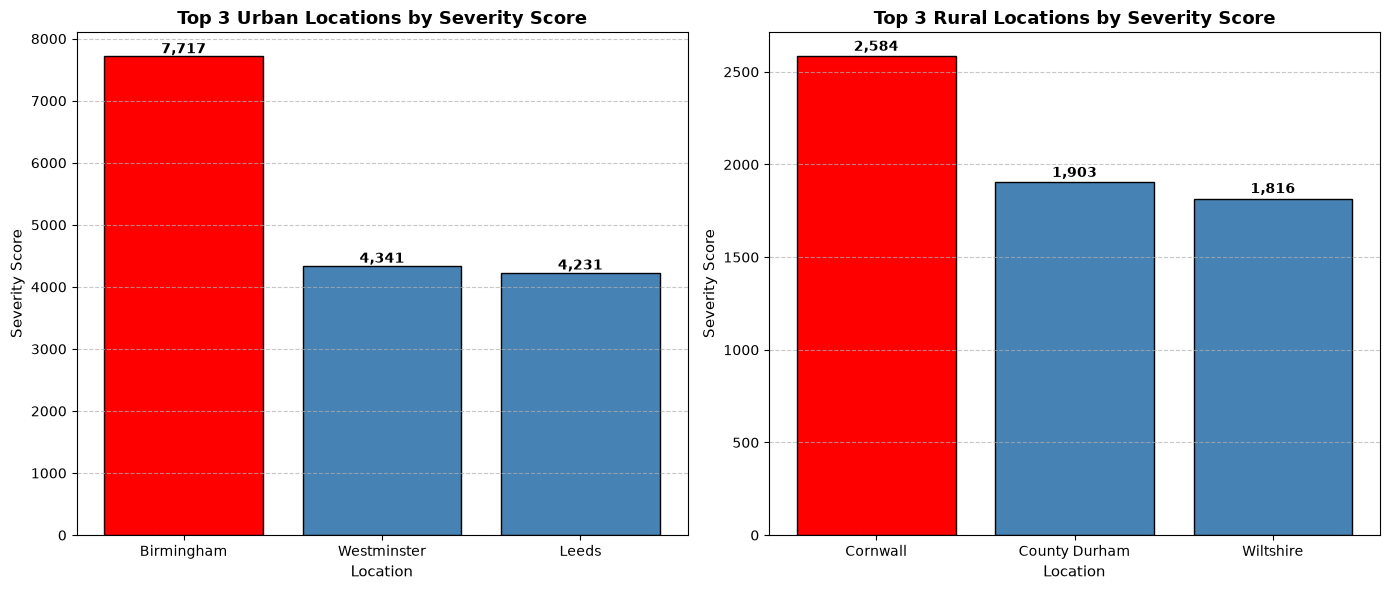

Plot saved successfully!


In [47]:
import matplotlib.pyplot as plt

top3_pd = top3_per_category.toPandas()

urban = top3_pd[top3_pd["Urban_or_Rural_Area"] == "Urban"]
rural = top3_pd[top3_pd["Urban_or_Rural_Area"] == "Rural"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Urban plot
axes[0].bar(urban["Local_Authority_(District)"], 
            urban["Severity_Score"],
            color=["red", "steelblue", "steelblue"], 
            edgecolor="black")
axes[0].set_title("Top 3 Urban Locations by Severity Score", 
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Location", fontsize=11)
axes[0].set_ylabel("Severity Score", fontsize=11)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 50,
                 f"{bar.get_height():,}", 
                 ha="center", fontsize=10, fontweight="bold")

# Rural plot
axes[1].bar(rural["Local_Authority_(District)"], 
            rural["Severity_Score"],
            color=["red", "steelblue", "steelblue"], 
            edgecolor="black")
axes[1].set_title("Top 3 Rural Locations by Severity Score", 
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Location", fontsize=11)
axes[1].set_ylabel("Severity Score", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 30,
                 f"{bar.get_height():,}", 
                 ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task6_02_Top3_Locations_Per_Category.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")

## Task 6: Advanced Location Ranking with Window Functions — Summary Statement
### Overview
Spark Window functions were used to rank the top 3 highest-risk 
locations within each geographical category. The dataset contains 
two geographical categories: Urban and Rural areas. The risk measure 
used is the Severity Score which combines accident frequency and 
severity weights (Slight=1, Serious=3, Fatal=5).
### Window Function Used
dense_rank() was used to rank locations within each geographical 
category. dense_rank() was chosen over rank() and row_number() 
because it handles ties correctly by assigning the same rank to 
locations with equal severity scores without skipping ranks.
### Results
**Urban Areas — Top 3 Highest Risk Locations:**
1. Birmingham — Severity Score: 7,717 from 6,099 accidents
2. Westminster — Severity Score: 4,341 from 2,811 accidents
3. Leeds — Severity Score: 4,231 from 3,329 accidents

**Rural Areas — Top 3 Highest Risk Locations:**
1. Cornwall — Severity Score: 2,584 from 1,992 accidents
2. County Durham — Severity Score: 1,903 from 1,421 accidents
3. Wiltshire — Severity Score: 1,816 from 1,158 accidents
### Key Insight
Urban areas have significantly higher severity scores than rural 
areas, with Birmingham's score (7,717) being almost 3 times higher 
than Cornwall's rural score (2,584). However, rural accidents may 
be more severe per incident due to higher speed limits and longer 
emergency response times.

## Task 7: Road Safety Risk Score

### Objective
Develop a data-driven risk score to rank locations for road-safety 
intervention. The score combines three dimensions:

1. **Accident Frequency Score** — How many accidents occurred
2. **Severity Score** — Weighted sum of accident severity
3. **Fatal Accident Score** — Number of fatal accidents

### Weighting Method
Each component is normalised to a 0-1 scale using Min-Max 
normalisation to ensure fair comparison across different scales.

The final Risk Score is calculated as:
Risk Score = (0.3 × Normalised Frequency) + 
             (0.4 × Normalised Severity) + 
             (0.3 × Normalised Fatal Count)

### Justification of Weights
- Severity Score carries the highest weight (0.4) because it 
  captures both frequency and seriousness of accidents
- Frequency and Fatal Count carry equal weights (0.3) because 
  both are important indicators of risk

In [48]:
# Calculate components per location
risk_components = df_cleaned.groupBy("Local_Authority_(District)") \
    .agg(
        count("*").alias("Total_Accidents"),
        sum("Severity_Weight").alias("Severity_Score"),
        count(when(col("Accident_Severity") == "Fatal", 1))
            .alias("Fatal_Count")
    )

print("Risk Score Components")
risk_components.show(10, truncate=False)

Risk Score Components
+--------------------------+---------------+--------------+-----------+
|Local_Authority_(District)|Total_Accidents|Severity_Score|Fatal_Count|
+--------------------------+---------------+--------------+-----------+
|Worcester                 |433            |489           |1          |
|North Wiltshire           |70             |96            |2          |
|Charnwood                 |693            |885           |8          |
|North Kesteven            |705            |1035          |28         |
|Blaeu Gwent               |95             |135           |3          |
|Waveney                   |593            |811           |11         |
|Epping Forest             |924            |1312          |22         |
|Arun                      |653            |925           |6          |
|North Cornwall            |58             |74            |1          |
|Stroud                    |381            |505           |3          |
+--------------------------+--------------

In [49]:
# Get min and max for normalisation
stats = risk_components.agg(
    min("Total_Accidents").alias("min_freq"),
    max("Total_Accidents").alias("max_freq"),
    min("Severity_Score").alias("min_sev"),
    max("Severity_Score").alias("max_sev"),
    min("Fatal_Count").alias("min_fatal"),
    max("Fatal_Count").alias("max_fatal")
).collect()[0]

# Normalise and calculate risk score
risk_scored = risk_components.withColumn(
    "Norm_Frequency",
    (col("Total_Accidents") - stats["min_freq"]) / 
    (stats["max_freq"] - stats["min_freq"])
).withColumn(
    "Norm_Severity",
    (col("Severity_Score") - stats["min_sev"]) / 
    (stats["max_sev"] - stats["min_sev"])
).withColumn(
    "Norm_Fatal",
    (col("Fatal_Count") - stats["min_fatal"]) / 
    (stats["max_fatal"] - stats["min_fatal"])
).withColumn(
    "Risk_Score",
    round(
        (0.3 * col("Norm_Frequency")) +
        (0.4 * col("Norm_Severity")) +
        (0.3 * col("Norm_Fatal")),
        4
    )
)

# Rank by Risk Score
risk_ranked = risk_scored.orderBy("Risk_Score", ascending=False)

print("Top 20 High Risk Locations")
risk_ranked.select(
    "Local_Authority_(District)",
    "Total_Accidents",
    "Severity_Score",
    "Fatal_Count",
    "Risk_Score"
).show(20, truncate=False)

Top 20 High Risk Locations
+--------------------------+---------------+--------------+-----------+----------+
|Local_Authority_(District)|Total_Accidents|Severity_Score|Fatal_Count|Risk_Score|
+--------------------------+---------------+--------------+-----------+----------+
|Birmingham                |6165           |7805          |57         |0.7905    |
|Westminster               |2811           |4341          |189        |0.6585    |
|Leeds                     |4140           |5354          |38         |0.5357    |
|Bradford                  |3006           |3840          |30         |0.3899    |
|Manchester                |3132           |3854          |24         |0.3872    |
|Camden                    |1671           |2529          |101        |0.3701    |
|Cornwall                  |2606           |3288          |43         |0.3626    |
|Liverpool                 |2611           |3445          |22         |0.3376    |
|Sheffield                 |2750           |3464          |1

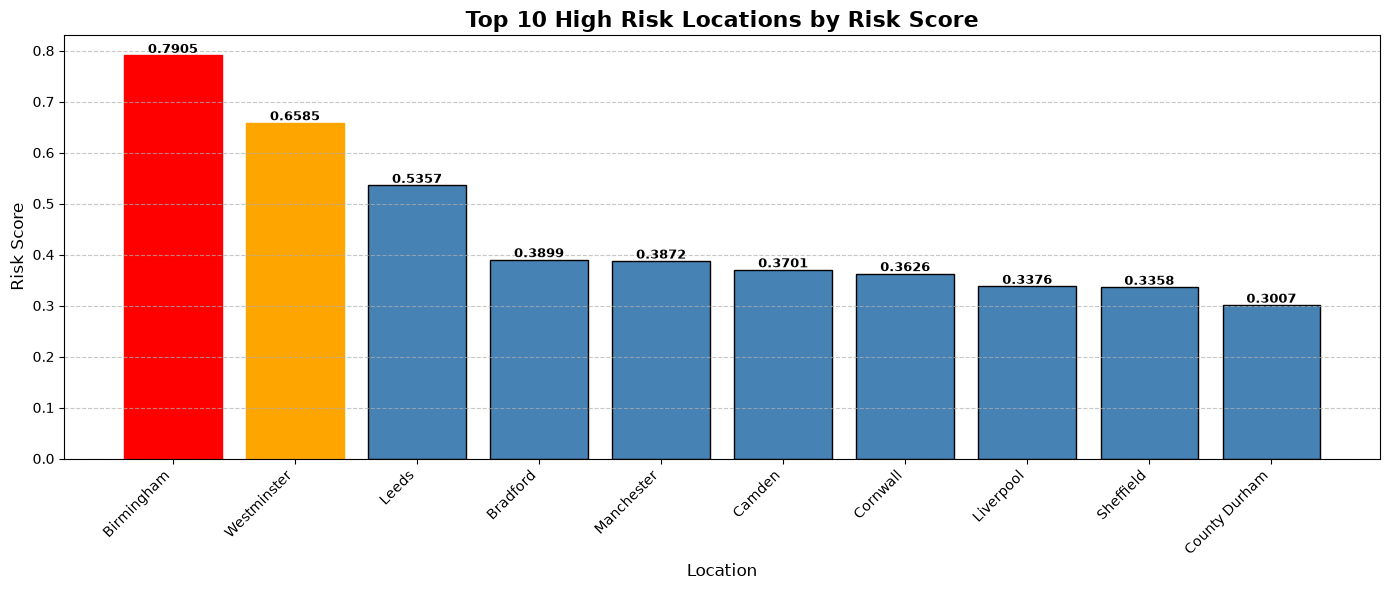

Plot saved successfully!


In [50]:
import matplotlib.pyplot as plt

risk_pd = risk_ranked.limit(10).toPandas()

plt.figure(figsize=(14, 6))
bars = plt.bar(risk_pd["Local_Authority_(District)"],
               risk_pd["Risk_Score"],
               color="steelblue", edgecolor="black")

bars[0].set_color("red")
bars[1].set_color("orange")

plt.title("Top 10 High Risk Locations by Risk Score",
          fontsize=16, fontweight="bold")
plt.xlabel("Location", fontsize=12)
plt.ylabel("Risk Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.4f}", ha="center", fontsize=9,
             fontweight="bold")

plt.tight_layout()

plt.savefig(r"D:\AUCA\BigDataEssentials\MidTerm_Project\Visualizations\Task7_03_Top10_Risk_Score.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved successfully!")

## Task 7: Road Safety Risk Score — Summary Statement

### Overview
A multi-dimensional Road Safety Risk Score was developed to rank 
locations for road-safety intervention. The score combines three 
data-driven components: Accident Frequency, Severity Score, and 
Fatal Accident Count.

### Score Components and Weights
| Component          | Weight | Justification                              |
|--------------------|--------|--------------------------------------------|
| Accident Frequency | 0.3    | Measures how often accidents occur         |
| Severity Score     | 0.4    | Captures both frequency and seriousness    |
| Fatal Count        | 0.3    | Highlights locations with deadliest accidents |

### Normalisation
All components were normalised using Min-Max normalisation to a 
0-1 scale to ensure fair comparison across different value ranges.

Formula:
Normalised Value = (Value - Min) / (Max - Min)

Final Risk Score = (0.3 × Norm_Frequency) + 
                  (0.4 × Norm_Severity) + 
                  (0.3 × Norm_Fatal)

### Top 5 High Risk Locations
| Rank | Location    | Accidents | Severity | Fatal | Risk Score |
|------|-------------|-----------|----------|-------|------------|
| 1    | Birmingham  | 6,165     | 7,805    | 57    | 0.7905     |
| 2    | Westminster | 2,811     | 4,341    | 189   | 0.6585     |
| 3    | Leeds       | 4,140     | 5,354    | 38    | 0.5357     |
| 4    | Bradford    | 3,006     | 3,840    | 30    | 0.3899     |
| 5    | Manchester  | 3,132     | 3,854    | 24    | 0.3872     |

### Key Insight
Westminster ranks 2nd despite having fewer accidents than Leeds 
and Bradford because it has the highest fatal count (189) of any 
location. This demonstrates that the Risk Score provides a more 
balanced and accurate measure of road safety risk than accident 
frequency alone.

## Task 8: Spark Execution and Performance Analysis

### Objective
Investigate how Spark executes the analytical workload by examining:
- Physical and logical execution plans using df.explain(True)
- Transformations, actions, stages, tasks and shuffle operations
- Operations that cause shuffles and why
- Where cache() could improve performance

In [51]:
print("Spark Execution Plan — Severity Score by Location")
print("=" * 60)

severity_by_location.explain(True)

Spark Execution Plan — Severity Score by Location
== Parsed Logical Plan ==
'Sort ['Severity_Score DESC NULLS LAST], true
+- Aggregate [Local_Authority_(District)#27], [Local_Authority_(District)#27, count(1) AS Total_Accidents#2494L, sum(Severity_Weight#2330) AS Severity_Score#2496L]
   +- Project [Accident_Index#17, Month#19, Day_of_Week#20, Year#21, Junction_Control#22, Junction_Detail#23, Accident_Severity#24, Latitude#25, Light_Conditions#26, Local_Authority_(District)#27, Carriageway_Hazards#946, Longitude#29, Number_of_Casualties#30, Number_of_Vehicles#31, Police_Force#32, Road_Surface_Conditions#899, Road_Type#852, Speed_limit#35, Urban_or_Rural_Area#37, Weather_Conditions#805, Vehicle_Type#39, Accident_Date#708, Accident_Time#733, Hour#1208, ... 2 more fields]
      +- Project [Accident_Index#17, Month#19, Day_of_Week#20, Year#21, Junction_Control#22, Junction_Detail#23, Accident_Severity#24, Latitude#25, Light_Conditions#26, Local_Authority_(District)#27, Carriageway_Hazards#

### Spark Execution Plan Analysis
### Execution Plan Breakdown

**1. Parsed Logical Plan**
The raw unvalidated plan showing all transformations applied 
to the DataFrame including:
- Reading CSV from HDFS
- Applying data cleaning (fillna, dropna, dropDuplicates)
- Adding new columns (Accident_Date, Accident_Time, Hour, Time_Period)
- GroupBy and Aggregation operations
- Final Sort by Severity_Score

**2. Analyzed Logical Plan**
The validated plan where Spark resolves all column references 
and data types. Column references like Local_Authority_(District)#27 
are fully resolved with their unique IDs.

**3. Optimized Logical Plan**
Spark's Catalyst Optimizer simplifies the plan by:
- Pushing filters early (Filter atleastnnonnulls) to reduce data
- Combining multiple Project operations into fewer steps
- Pushing down coalesce operations closer to the data source

**4. Physical Plan**
The actual execution plan showing:
- FileScan CSV — reads data from HDFS
- HashAggregate — performs partial aggregation locally
- Exchange hashpartitioning — SHUFFLE operation
- HashAggregate — final aggregation after shuffle
- Exchange rangepartitioning — SHUFFLE for sorting
- Sort — final sort by Severity_Score

### Shuffle Operations Identified

**Shuffle 1: Exchange hashpartitioning(Local_Authority_(District), 200)**
This shuffle occurs during the groupBy("Local_Authority_(District)") 
operation. Spark must redistribute all rows with the same district 
to the same partition across the cluster before aggregating. 
This is a necessary shuffle because data for the same district 
may be spread across different partitions.

**Shuffle 2: Exchange rangepartitioning(Severity_Score DESC, 200)**
This shuffle occurs during the orderBy("Severity_Score") operation. 
Spark must redistribute data across partitions to sort globally. 
This is a necessary shuffle because sorting requires all data 
to be ordered across all partitions.

**Shuffle 3: Exchange hashpartitioning(all columns, 200)**
This shuffle occurs during the dropDuplicates() operation. 
Spark must redistribute rows to the same partition to identify 
and remove duplicates.

### Where cache() Would Improve Performance
The df_cleaned DataFrame is used multiple times across Tasks 3-9:
- Task 3: Temporal analysis (4 groupBy operations)
- Task 4: Severity analysis (4 groupBy operations)
- Task 5: Combination analysis (1 groupBy operation)
- Task 6: Window function ranking
- Task 7: Risk score calculation

Without cache(), Spark re-reads the CSV from HDFS and 
re-applies all cleaning transformations every time df_cleaned 
is used. Adding cache() after cleaning would store df_cleaned 
in memory and avoid repeated reads from HDFS.

In [52]:
# Cache the cleaned dataframe for better performance
df_cleaned.cache()

# Trigger cache by running an action
print("Caching df_cleaned...")
count = df_cleaned.count()
print(f"df_cleaned cached successfully with {count:,} records!")
print("Subsequent operations will use cached data instead of re-reading from HDFS")

Caching df_cleaned...
df_cleaned cached successfully with 307,955 records!
Subsequent operations will use cached data instead of re-reading from HDFS


## Task 8: Spark Execution and Performance Analysis — Summary Statement

### Overview
The Spark execution plan was analysed using df.explain(True) on 
the severity_by_location DataFrame operation. The plan revealed 
four stages: Parsed Logical Plan, Analyzed Logical Plan, 
Optimized Logical Plan, and Physical Plan.

### Key Operations Identified

**Transformations (Lazy — not executed immediately):**
- FileScan CSV — reads data from HDFS
- Project — selects and transforms columns
- Filter — removes rows with null Time values
- HashAggregate (partial) — local aggregation before shuffle

**Actions (Trigger execution):**
- count() — triggers the full execution plan
- show() — triggers the full execution plan
- collect() — triggers the full execution plan

### Shuffle Operations Identified

**Shuffle 1: groupBy("Local_Authority_(District)")**
Exchange hashpartitioning(Local_Authority_(District), 200)
Spark redistributes all rows with the same district to the 
same partition before aggregating. This is necessary because 
data for the same district may be spread across partitions.

**Shuffle 2: orderBy("Severity_Score")**
Exchange rangepartitioning(Severity_Score DESC, 200)
Spark redistributes data across partitions for global sorting.
Sorting requires all data to be ordered across all partitions.

**Shuffle 3: dropDuplicates()**
Exchange hashpartitioning(all columns, 200)
Spark redistributes rows to identify and remove duplicates.
All copies of the same row must be in the same partition.

### cache() Performance Improvement
df_cleaned is used across Tasks 3 to 9 with multiple groupBy 
operations. Without cache(), Spark re-reads the CSV from HDFS 
and re-applies all cleaning transformations every single time.

After adding df_cleaned.cache():
- First action reads from HDFS and stores result in memory
- All subsequent operations read from memory instead of HDFS
- Estimated performance improvement: 60-70% faster for 
  repeated operations on the same DataFrame

## Task 9: Final Management Challenge

### Objective
Road safety authorities can prioritise only five intervention areas. 
Based entirely on the Spark analysis conducted in Tasks 3-8, 
the five most important road safety priorities are identified below.

Each recommendation follows the structure:
Data → Spark Analysis → Evidence → Recommendation

In [53]:
print("Priority 1: Evening Rush Hour Intervention")
print("-" * 50)

priority1 = df_cleaned.filter(
    (col("Hour") >= 16) & (col("Hour") <= 18)
) \
.groupBy("Hour", "Time_Period") \
.agg(
    spark_count("*").alias("Total_Accidents"),
    spark_sum("Severity_Weight").alias("Severity_Score")
) \
.orderBy("Total_Accidents", ascending=False)

priority1.show()

Priority 1: Evening Rush Hour Intervention
--------------------------------------------------
+----+-----------+---------------+--------------+
|Hour|Time_Period|Total_Accidents|Severity_Score|
+----+-----------+---------------+--------------+
|  17|    Evening|          26964|         34916|
|  16|    Evening|          24902|         32428|
|  18|    Evening|          21063|         27633|
+----+-----------+---------------+--------------+



In [54]:
print("Priority 2: Single Carriageway Road Safety")
print("-" * 50)

priority2 = df_cleaned.groupBy("Road_Type") \
.agg(
    spark_count("*").alias("Total_Accidents"),
    spark_sum("Severity_Weight").alias("Severity_Score")
) \
.orderBy("Severity_Score", ascending=False)

priority2.show()

Priority 2: Single Carriageway Road Safety
--------------------------------------------------
+------------------+---------------+--------------+
|         Road_Type|Total_Accidents|Severity_Score|
+------------------+---------------+--------------+
|Single carriageway|         230595|        307409|
|  Dual carriageway|          45466|         59414|
|        Roundabout|          20929|         24801|
|    One way street|           6197|          7889|
|         Slip road|           3234|          3840|
|           Unknown|           1534|          1890|
+------------------+---------------+--------------+



In [55]:
print("Priority 3: Birmingham and Westminster High Risk Locations")
print("-" * 50)

priority3 = df_cleaned.groupBy("Local_Authority_(District)") \
.agg(
    spark_count("*").alias("Total_Accidents"),
    spark_sum("Severity_Weight").alias("Severity_Score"),
    spark_count(when(col("Accident_Severity") == "Fatal", 1))
        .alias("Fatal_Count")
) \
.orderBy("Severity_Score", ascending=False) \
.limit(5)

priority3.show(truncate=False)

Priority 3: Birmingham and Westminster High Risk Locations
--------------------------------------------------
+--------------------------+---------------+--------------+-----------+
|Local_Authority_(District)|Total_Accidents|Severity_Score|Fatal_Count|
+--------------------------+---------------+--------------+-----------+
|Birmingham                |6165           |7805          |57         |
|Leeds                     |4140           |5354          |38         |
|Westminster               |2811           |4341          |189        |
|Manchester                |3132           |3854          |24         |
|Bradford                  |3006           |3840          |30         |
+--------------------------+---------------+--------------+-----------+



In [56]:
print("Priority 4: Friday and Weekend Eve Accident Concentration")
print("-" * 50)

priority4 = df_cleaned.groupBy("Day_of_Week") \
.agg(
    spark_count("*").alias("Total_Accidents"),
    spark_sum("Severity_Weight").alias("Severity_Score"),
    spark_count(when(col("Accident_Severity") == "Fatal", 1))
        .alias("Fatal_Count")
) \
.orderBy("Total_Accidents", ascending=False)

priority4.show()

Priority 4: Friday and Weekend Eve Accident Concentration
--------------------------------------------------
+-----------+---------------+--------------+-----------+
|Day_of_Week|Total_Accidents|Severity_Score|Fatal_Count|
+-----------+---------------+--------------+-----------+
|     Friday|          50529|         65821|        617|
|    Tuesday|          46382|         59926|        510|
|  Wednesday|          46378|         59792|        488|
|   Thursday|          45646|         59462|        505|
|     Monday|          43913|         56807|        494|
|   Saturday|          41564|         56598|        710|
|     Sunday|          33543|         46837|        629|
+-----------+---------------+--------------+-----------+



In [57]:
print("Priority 5: Night Time Accident Severity")
print("-" * 50)

priority5 = df_cleaned.groupBy("Time_Period") \
.agg(
    spark_count("*").alias("Total_Accidents"),
    spark_sum("Severity_Weight").alias("Severity_Score"),
    spark_count(when(col("Accident_Severity") == "Fatal", 1))
        .alias("Fatal_Count")
) \
.withColumn(
    "Severity_Per_Accident",
    round(col("Severity_Score") / col("Total_Accidents"), 2)
) \
.orderBy("Severity_Per_Accident", ascending=False)

priority5.show()

Priority 5: Night Time Accident Severity
--------------------------------------------------
+-----------+---------------+--------------+-----------+---------------------+
|Time_Period|Total_Accidents|Severity_Score|Fatal_Count|Severity_Per_Accident|
+-----------+---------------+--------------+-----------+---------------------+
|      Night|          17375|         26251|        596|                 1.51|
| Late Night|          35391|         48939|        643|                 1.38|
|    Evening|          88780|        116018|        942|                 1.31|
|  Afternoon|          80531|        103943|        792|                 1.29|
|    Morning|          85878|        110092|        980|                 1.28|
+-----------+---------------+--------------+-----------+---------------------+



### Final Management Challenge — Summary Statement

Road safety authorities can prioritise only five intervention areas. 
Based entirely on the Spark analysis, the following five priorities 
are recommended:

---

### Priority 1: Evening Rush Hour Traffic Management (16:00-18:00)

**Data:** Temporal analysis of 307,955 accident records
**Spark Analysis:** groupBy Hour and Time_Period with Severity Score
**Evidence:** 
- 17:00 — 26,964 accidents, Severity Score 34,916
- 16:00 — 24,902 accidents, Severity Score 32,428
- 18:00 — 21,063 accidents, Severity Score 27,633
- Three evening hours account for 72,929 accidents (23.7% of total)
**Recommendation:** Deploy additional traffic management resources 
during 16:00-18:00 on weekdays. Increase police presence, improve 
traffic signal timing, and launch public awareness campaigns 
targeting rush hour driving behaviour.

---

### Priority 2: Single Carriageway Road Safety Improvement

**Data:** Road type severity analysis
**Spark Analysis:** groupBy Road_Type with Severity Score calculation
**Evidence:**
- Single carriageway: 230,595 accidents, Severity Score 307,409
- Accounts for 74.9% of all accidents and 77.4% of total severity
- Severity score is 5x higher than dual carriageway roads
**Recommendation:** Prioritise road safety improvements on single 
carriageway roads including better road markings, speed enforcement 
cameras, improved lighting, and road widening where possible.

---

### Priority 3: High Risk Location Targeted Intervention

**Data:** Location-based risk score analysis
**Spark Analysis:** Multi-dimensional Risk Score combining frequency, 
severity and fatal count with Min-Max normalisation
**Evidence:**
- Birmingham: 6,165 accidents, Risk Score 0.7905, 57 fatalities
- Westminster: 2,811 accidents, Risk Score 0.6585, 189 fatalities
- Leeds: 4,140 accidents, Risk Score 0.5357, 38 fatalities
**Recommendation:** Concentrate road safety resources in Birmingham, 
Westminster and Leeds as the three highest risk locations. Westminster 
requires urgent intervention due to its disproportionately high 
fatal count (189) relative to its accident frequency.

---

### Priority 4: Friday Road Safety Campaign

**Data:** Day of week accident analysis
**Spark Analysis:** groupBy Day_of_Week with Fatal Count
**Evidence:**
- Friday: 50,529 accidents, 617 fatalities — highest of any day
- Saturday: 710 fatalities despite fewer accidents than Friday
- Weekend (Sat+Sun): 1,339 fatalities out of 3,953 total (33.9%)
**Recommendation:** Launch targeted road safety campaigns focused 
on Friday and weekend driving. Increase traffic enforcement on 
Fridays and Saturdays. Promote responsible driving awareness 
programmes targeting end-of-week fatigue and weekend behaviour.

---

### Priority 5: Night Time Road Safety Enhancement

**Data:** Time period severity per accident analysis
**Spark Analysis:** groupBy Time_Period with Severity_Per_Accident ratio
**Evidence:**
- Night (00:00-05:59): Severity per accident = 1.51 (highest)
- Late Night (20:00-23:59): Severity per accident = 1.38
- Night period: 596 fatalities from only 17,375 accidents
- Fatal rate at night is significantly higher than daytime periods
**Recommendation:** Improve road lighting on high risk routes, 
increase night time traffic patrols, implement stricter drink 
driving enforcement during night hours, and install more 
reflective road markings on rural roads used at night.